# EDA — Banca Pasivo

---
## 0. Configuración del Dataset

In [37]:
# ============================================================
# CONFIGURACIÓN: BANCA_PASIVO
# ============================================================

DATASET_CONFIG = {
    'nombre': 'banca_pasivo',
    'archivo': 'ed_pasivo_historico_1962_2026.csv',
'frecuencia_original': 'mensual',
    'col_fecha': 'fecha',
    'variable_principal': 'ed_pasivo_depositos_total',
    'variables_desgloses': [
        'ed_pasivo_depositos_esp',
        'ed_pasivo_sector_privado',
        'ed_pasivo_deposito_resto_mundo',
        'ed_pasivo_depositos_sector_publico',
    ],
    'columnas_numericas': [
        'ed_pasivo_total',
        'ed_pasivo_depositos_total',
        'ed_pasivo_depositos_esp',
        'ed_pasivo_depositos_sector_publico',
        'ed_pasivo_sector_privado',
        'ed_pasivo_deposito_resto_mundo',
        'ed_pasivo_deuda_emitida',
        'ed_pasivo_patrimonio_ajustes',
    ],
    'unidades': 'millones EUR constantes 2025',
    'notas': 'Banco de España. Entidades de depósito: pasivo. Mensual desde 1962.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: banca_pasivo
Variable principal:  ed_pasivo_depositos_total
Frecuencia:          mensual
Periodo estacional:  12


---
## Imports

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}

---
## 1. Carga y Diagnóstico Básico

In [39]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: banca_pasivo
Notas:   Banco de España. Entidades de depósito: pasivo. Mensual desde 1962.
Shape:          (616, 12)
Rango temporal: 1974-07-01 a 2025-10-01
Observaciones:  616
Columnas:       ['año', 'mes', 'ed_pasivo_total', 'ed_pasivo_depositos_total', 'ed_pasivo_depositos_esp', 'ed_pasivo_depositos_sector_publico', 'ed_pasivo_sector_privado', 'ed_pasivo_deposito_resto_mundo', 'ed_pasivo_deuda_emitida', 'ed_pasivo_patrimonio_ajustes', 'ec_efc_pasivo_obra_social', 'ed_pasivo_periodificacion_otros']


In [40]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,mes,ed_pasivo_total,ed_pasivo_depositos_total,ed_pasivo_depositos_esp,ed_pasivo_depositos_sector_publico,ed_pasivo_sector_privado,ed_pasivo_deposito_resto_mundo,ed_pasivo_deuda_emitida,ed_pasivo_patrimonio_ajustes,ec_efc_pasivo_obra_social,ed_pasivo_periodificacion_otros
fecha,,,,,,,,,,,,
1974-07-01,1974,7,NaN,476054.392,58530.868,3689.456,383421.554,30412.497,15486.293,NaN,1931.370,12924.512
1974-08-01,1974,8,NaN,465034.444,55088.109,3755.363,377913.831,28277.142,15475.575,NaN,1896.808,10365.065
1974-09-01,1974,9,NaN,462638.177,53185.254,3804.980,378643.565,27004.377,15323.780,NaN,1868.860,10655.179



Últimas 3 filas:


,año,mes,ed_pasivo_total,ed_pasivo_depositos_total,ed_pasivo_depositos_esp,ed_pasivo_depositos_sector_publico,ed_pasivo_sector_privado,ed_pasivo_deposito_resto_mundo,ed_pasivo_deuda_emitida,ed_pasivo_patrimonio_ajustes,ec_efc_pasivo_obra_social,ed_pasivo_periodificacion_otros
fecha,,,,,,,,,,,,
2025-08-01,2025,8,3075660.407,2287943.510,94047.799,200237.402,1526999.804,466658.505,283460.450,319483.640,399.985,184372.822
2025-09-01,2025,9,3078678.352,2284871.604,91564.181,196336.483,1538477.873,458493.067,278392.517,317182.664,410.487,197821.081
2025-10-01,2025,10,3103338.294,2312839.310,89930.585,200993.558,1517376.035,504539.132,276233.009,312282.206,410.537,201573.232


In [41]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
ed_pasivo_total,371,60.230,2005-06-01,2025-10-01
ed_pasivo_depositos_total,0,0.000,1974-07-01,2025-10-01
ed_pasivo_depositos_esp,0,0.000,1974-07-01,2025-10-01
ed_pasivo_depositos_sector_publico,0,0.000,1974-07-01,2025-10-01
ed_pasivo_sector_privado,0,0.000,1974-07-01,2025-10-01
ed_pasivo_deposito_resto_mundo,0,0.000,1974-07-01,2025-10-01
ed_pasivo_deuda_emitida,0,0.000,1974-07-01,2025-10-01
ed_pasivo_patrimonio_ajustes,371,60.230,2005-06-01,2025-10-01



Duplicados de fecha: 0


In [42]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 31 days 00:00:00
Intervalo mínimo:                      28 days 00:00:00
Intervalo máximo:                      31 days 00:00:00


---
## 2. Series Temporales

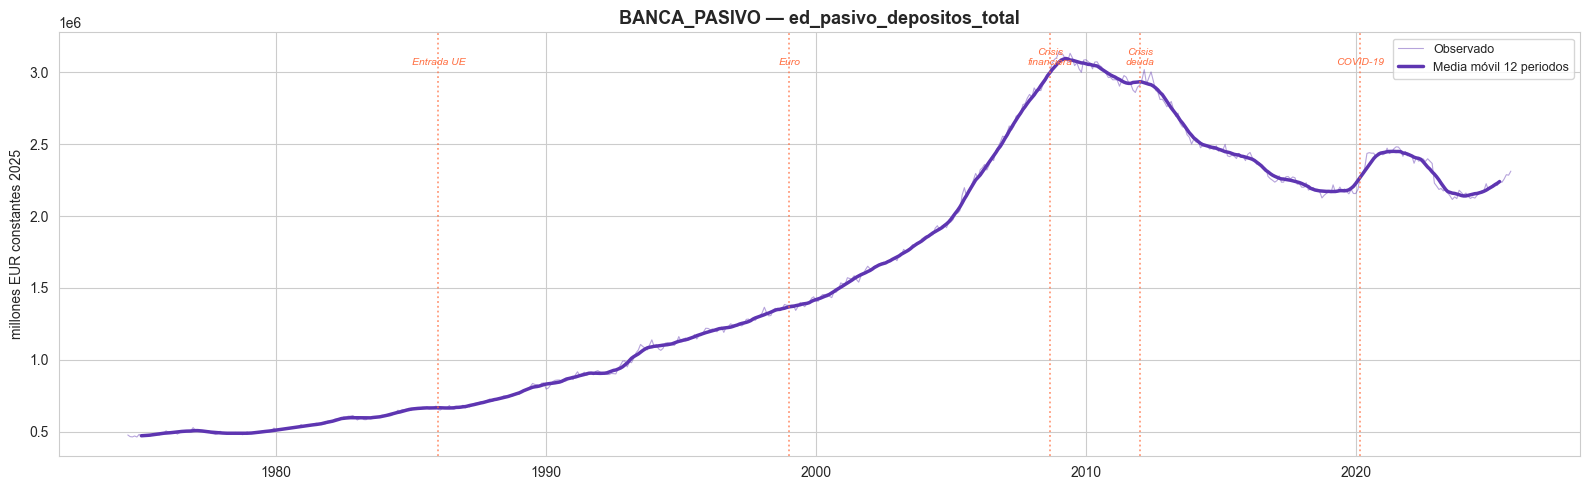

Mín: 462076.11  (1974-11-01)
Máx: 3144888.33  (2009-01-01)


In [43]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

`ed_pasivo_depositos_total` es una serie no estacionaria con tendencia alcista dominante hasta 2009 y contracción posterior. Medida en euros constantes de 2025, parte de su mínimo de 462.076,11 millones en noviembre de 1974 y crece de forma sostenida hasta el máximo de 3.144.888,33 millones (aproximadamente 3,14 billones) en enero de 2009. A partir de ese punto la media móvil de 12 periodos describe un descenso prolongado que estabiliza la serie en torno a 2,15 y 2,30 billones en la última década, con un repunte final hacia 2,30. La trayectoria atraviesa los hitos señalados, entrada en la UE, euro, crisis financiera, crisis de deuda y COVID-19, sin revertir al nivel previo a la expansión, lo que descarta un comportamiento estacionario en media. El perfil es coherente con el de `ed_activo_total`. La forma estacionaria concreta se resuelve en el bloque de transformación.

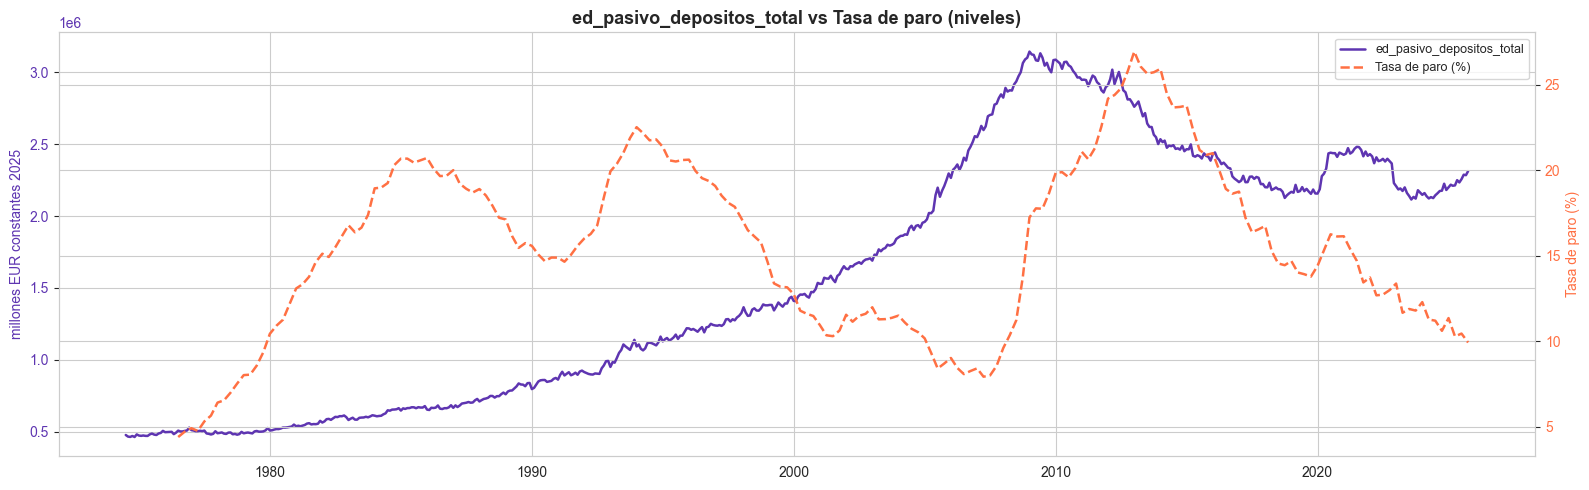

In [44]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La comparación en niveles entre `ed_pasivo_depositos_total` y la tasa de paro muestra un co-movimiento cuyo signo cambia a lo largo del periodo. Entre 1974 y 1985 las dos series suben conjuntamente: el paro recorre de aproximadamente el 5% al 20% mientras los depósitos bancarios crecen de aproximadamente 0,46 a 0,65 billones EUR constantes de 2025, con co-movimiento positivo asociado a la fase de ajuste posterior a la crisis del petróleo.

Entre 1985 y 2007 la relación se invierte. Los depósitos crecen de forma sostenida hasta aproximadamente 2,3 billones mientras el paro alterna dos máximos próximos al 20% en 1985 y al 22% en 1994 y desciende hasta el mínimo de aproximadamente el 8% en 2007. Las dos series se cruzan visualmente en torno a 1999-2000 y el co-movimiento es negativo durante todo el tramo, coincidente con la expansión del balance bancario previa a la crisis financiera.

Entre 2007 y 2013 vuelve a aparecer co-movimiento positivo en la primera mitad del tramo: ambas series suben, con el paro hasta su máximo de aproximadamente el 27% en 2013 y los depósitos hasta su máximo de aproximadamente 3,14 billones en 2009, tras el cual entran en descenso. El máximo de los depósitos precede en aproximadamente tres años al máximo del paro, lo que adelanta la inversión del co-movimiento respecto al tramo final. A partir de 2013 el paro desciende hasta aproximadamente el 10% al final de la muestra mientras los depósitos bajan hasta aproximadamente 2,15 billones hacia 2018-2019, repuntan a 2,45 en 2021 y se mueven entre 2,15 y 2,30 billones en los últimos años. El cambio de signo del co-movimiento a lo largo del periodo y el carácter no estacionario de las dos series indican que la relación contemporánea en niveles está dominada por las tendencias compartidas y enmascara la dinámica cíclica subyacente, que se analiza en la sección 9 sobre las formas estacionarias correspondientes.

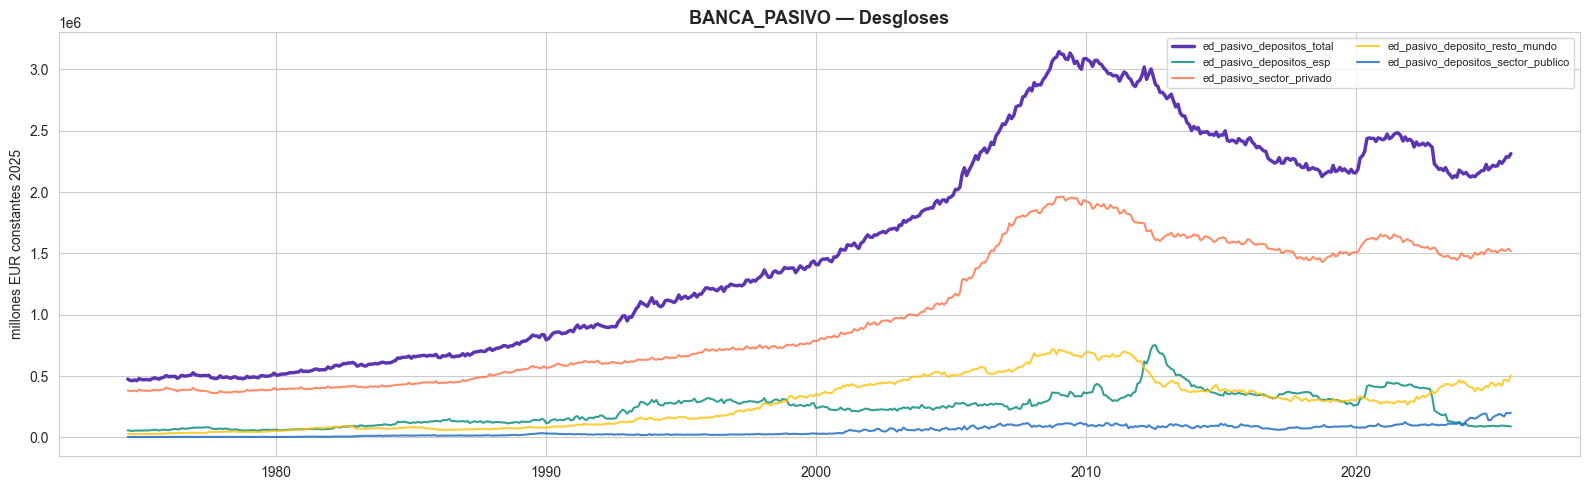

In [45]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=2.5, label=VAR_PRINCIPAL, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(UNIDADES, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

El agregado de depósitos está dominado por `ed_pasivo_sector_privado`, cuya forma reproduce la del total y alcanza aproximadamente 1,95 billones en su máximo de 2009. Los depósitos del resto del mundo (`ed_pasivo_deposito_resto_mundo`) y los de entidades españolas (`ed_pasivo_depositos_esp`) constituyen componentes secundarios, de menor magnitud y mayor volatilidad relativa, con máximos próximos a 0,7 billones en el entorno de la crisis; `ed_pasivo_depositos_esp` presenta además saltos bruscos en los últimos años de la muestra. Los depósitos del sector público (`ed_pasivo_depositos_sector_publico`) se mantienen marginales durante todo el periodo, por debajo de 0,15 billones. La no estacionariedad del total se hereda directamente del componente privado, mientras que los componentes menores concentran la mayor parte de la variabilidad de corto plazo. La caracterización estacionaria de cada componente se aborda en los bloques siguientes.

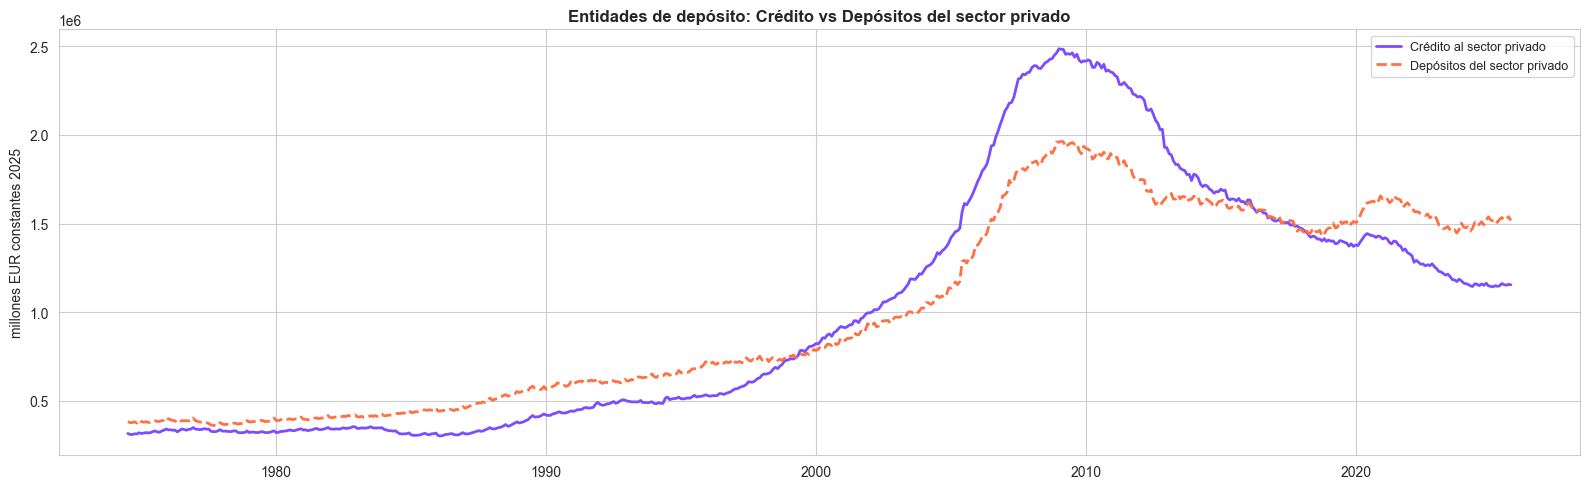

In [46]:
# Crédito vs Depósitos del sector privado
ruta_activo = RUTA_BASE / 'ed_activo_historico_1962_2026.csv'
df_activo = pd.read_csv(ruta_activo)
df_activo['fecha'] = pd.to_datetime(df_activo['fecha'])
df_activo = df_activo.set_index('fecha').sort_index()
for col in df_activo.columns:
    df_activo[col] = pd.to_numeric(df_activo[col], errors='coerce')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_activo['ed_activo_credito_sector_privado'].dropna().index,
        df_activo['ed_activo_credito_sector_privado'].dropna(),
        color='#7C4DFF', lw=2, label='Crédito al sector privado')
ax.plot(df['ed_pasivo_sector_privado'].dropna().index,
        df['ed_pasivo_sector_privado'].dropna(),
        color='#FF7043', lw=2, linestyle='--', label='Depósitos del sector privado')
ax.set_title('Entidades de depósito: Crédito vs Depósitos del sector privado',
             fontsize=12, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Análisis:

La relación entre crédito y depósitos del sector privado define un ciclo de financiación con inversión de signo. Hasta finales de los noventa los depósitos privados superan al crédito y lo financian con holgura. El crédito adelanta a los depósitos hacia 1999-2000 y abre una brecha creciente que culmina en 2009, con el crédito al sector privado en torno a 2,5 billones frente a depósitos cercanos a 1,95 billones. El desapalancamiento posterior reduce esa brecha y la invierte: desde aproximadamente 2016 los depósitos vuelven a situarse por encima del crédito, posición que se mantiene hasta el final de la muestra, con depósitos cercanos a 1,55 billones y crédito en torno a 1,15 en 2025. Ambas series son no estacionarias y comparten el máximo de 2009, lo que reproduce el patrón de la derivada `credito_privado_share`. La forma estacionaria de cada serie se determina en el bloque de transformación.

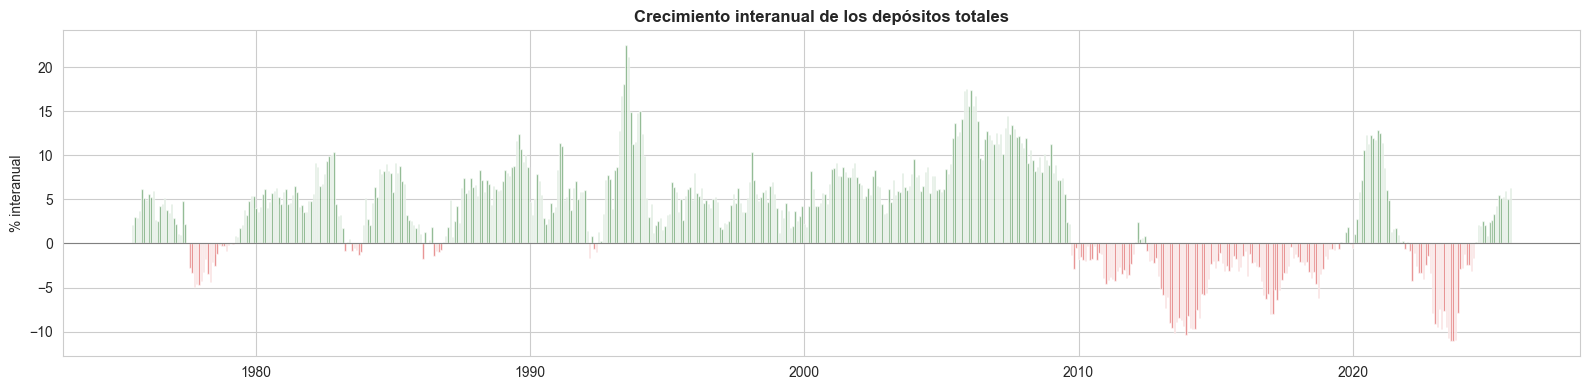

In [47]:
# Crecimiento interanual de los depósitos totales
if 'ed_pasivo_depositos_total' in df.columns:
    dep_yoy = df['ed_pasivo_depositos_total'].pct_change(12) * 100

    fig, ax = plt.subplots(figsize=(16, 4))
    colors = dep_yoy.apply(lambda x: '#2E7D32' if x >= 0 else '#D32F2F')
    ax.bar(dep_yoy.index, dep_yoy, color=colors, alpha=0.7, width=20)
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_title('Crecimiento interanual de los depósitos totales', fontsize=12, fontweight='bold')
    ax.set_ylabel('% interanual', fontsize=10)
    plt.tight_layout()
    plt.show()

### Análisis:

El crecimiento interanual de los depósitos totales alterna regímenes positivos y negativos sin estabilizarse en torno a una media constante. Predomina el terreno positivo, con un máximo que supera el 20% en 1993-1994, el más alto de la muestra, y un tramo que se mantiene por encima del 15% en 2006-2007, antes del cambio de signo asociado a la crisis. Se identifican dos regímenes claramente negativos: uno breve a finales de los setenta y otro prolongado entre 2011 y 2016 que se aproxima al -10%, con el mínimo de la serie en 2023, por debajo del -10% y próximo al -11%. El repunte de 2021, de aproximadamente el 12%, coincide con la inyección de liquidez del periodo COVID, asociación que queda como hipótesis no verificada. La amplitud de las oscilaciones interanuales aumenta a lo largo de la muestra, patrón de heterocedasticidad que se caracteriza en el bloque de estacionariedad. La forma estacionaria concreta se resuelve en la fase de feature engineering.

---
## 3. Distribución y Outliers

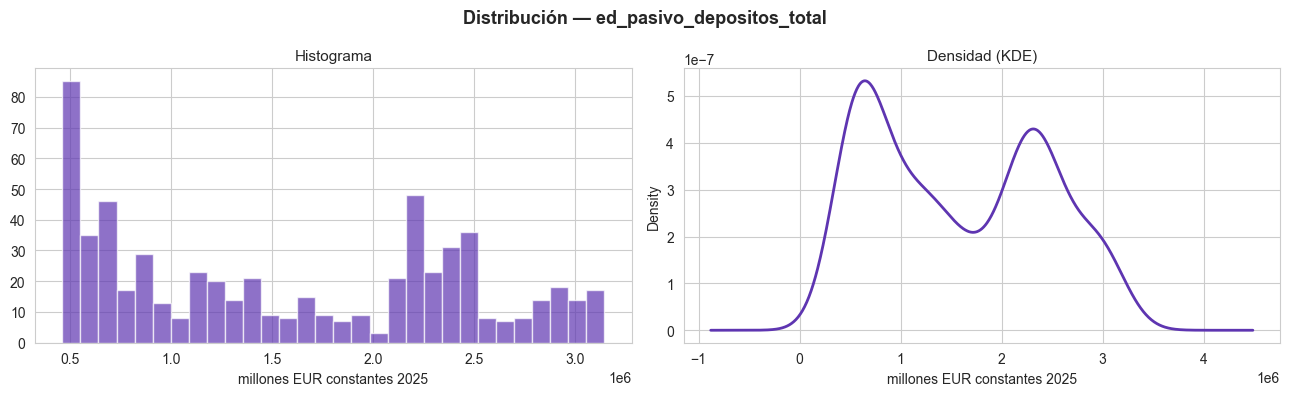

Asimetría (skewness): 0.192
Curtosis:             -1.402


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

La distribución muestral de `ed_pasivo_depositos_total` es bimodal, con una asimetría de 0,192 y una curtosis de -1,402. La densidad presenta dos modas claras separadas por un valle, una en torno a 0,65 billones y otra cercana a 2,3 billones, con la primera algo más alta. La asimetría próxima a cero y la curtosis marcadamente negativa, que indica una forma aplanada y platicúrtica, son consecuencia directa de esa bimodalidad y no de la forma de una distribución estacionaria: la serie no fluctúa alrededor de una media constante, sino que ha permanecido en dos regímenes de nivel diferenciados, el previo a la expansión y la meseta posterior a 2009. Los estadísticos de distribución sobre el nivel describen la ocupación temporal de esos niveles, no una ley estable.

In [49]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha       valor
1974-11-01  462076.108
1974-09-01  462638.177
1974-08-01  465034.444
1974-10-01  469265.880
1975-05-01  469562.361
2009-07-01 3103168.278
2009-03-01 3122079.222
2009-02-01 3125079.714
2009-06-01 3133081.135
2009-01-01 3144888.332


### Análisis:

`ed_pasivo_depositos_total` no contiene valores atípicos: el criterio IQR (1,5×) y el z-score (>3) identifican cero outliers. Los diez valores extremos corresponden a los puntos inicial y final de la trayectoria, no a anomalías. Los cinco mínimos se concentran entre agosto de 1974 y mayo de 1975, con el mínimo absoluto de 462.076,108 millones en noviembre de 1974. Los cinco máximos se sitúan todos en 2009, entre enero y julio, con el máximo absoluto de 3.144.888,332 millones en enero, lo que ubica el pico de la serie en el primer semestre de ese año. La ausencia de outliers es coherente con una serie de stock contable de evolución suave y reproduce el resultado de `ed_activo_total`.

In [50]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

El desglose por meses descarta estacionalidad mensual en `ed_pasivo_depositos_total`. Las doce distribuciones son prácticamente indistinguibles: las medianas se sitúan en torno a 1,4 billones en todos los meses, los rangos intercuartílicos abarcan aproximadamente de 0,65 a 2,3 billones y los bigotes cubren el recorrido completo de la serie, de aproximadamente 0,46 a 3,1 billones. Ningún mes presenta un nivel sistemáticamente superior ni una dispersión diferenciada. La amplitud de cada caja refleja que la serie ha atravesado todos los niveles a lo largo de la muestra, dominada por la tendencia y no por un patrón estacional. Este resultado es coherente con la ausencia de estacionalidad documentada en el notebook de activos de las entidades de depósito. La caracterización de la forma estacionaria se resuelve en la fase de feature engineering.

---
## 4. Estacionalidad

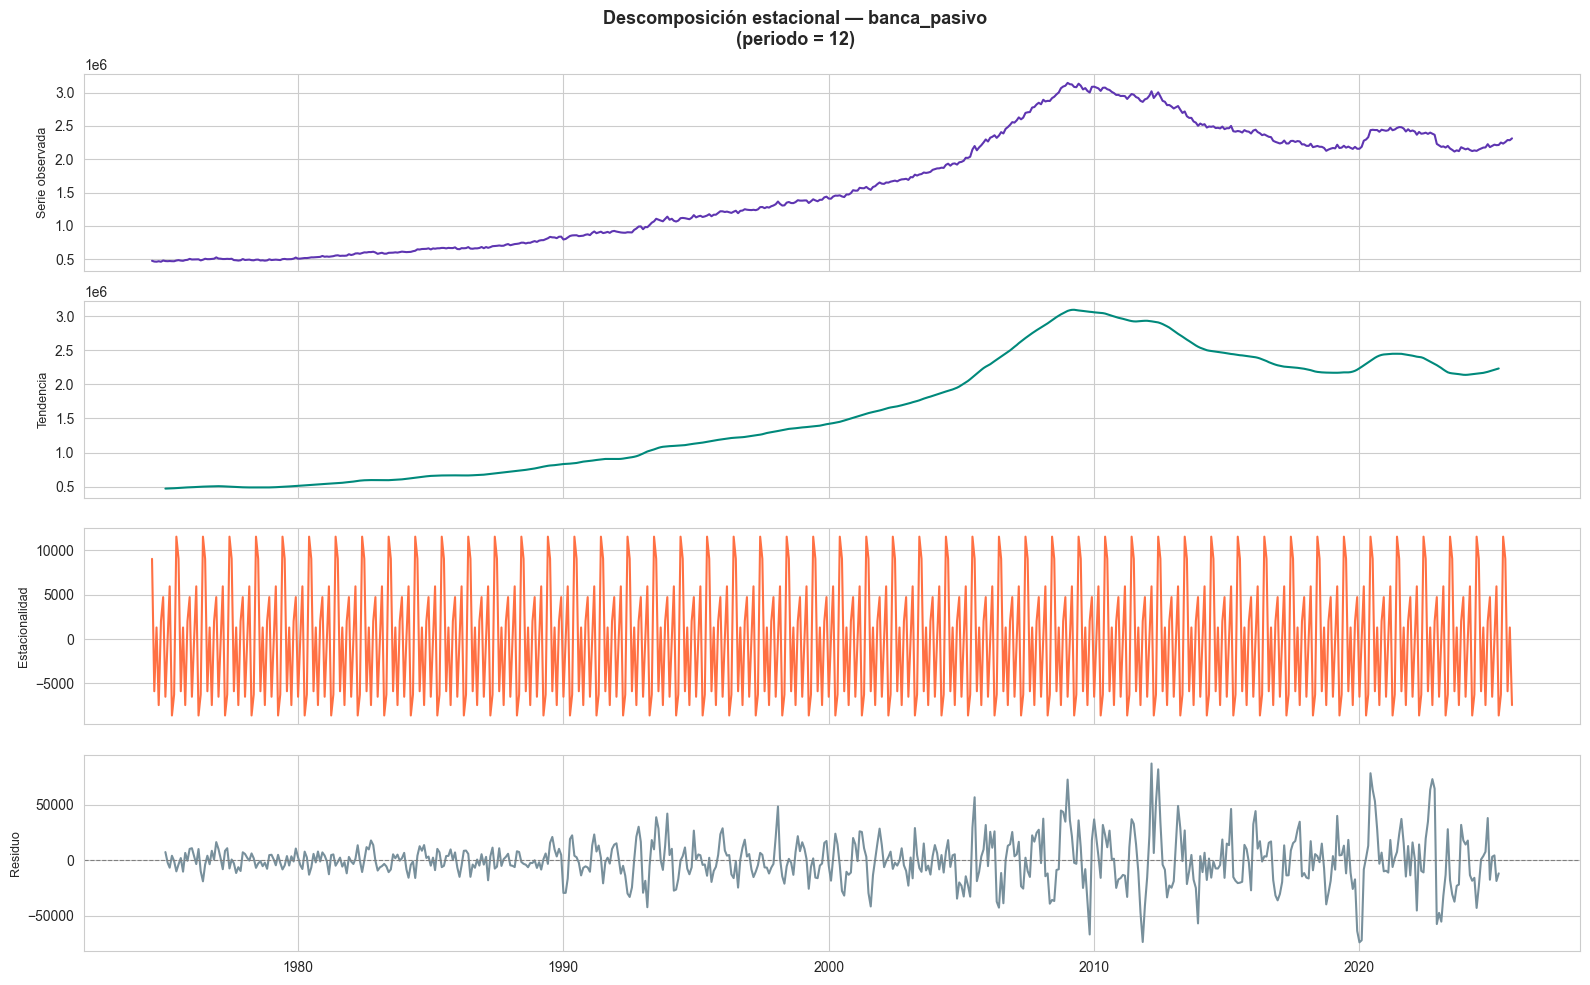

In [51]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición aditiva con periodo 12 sitúa la dinámica de `ed_pasivo_depositos_total` en la tendencia y el componente irregular, no en la estacionalidad. La componente de tendencia reproduce el perfil de la serie observada, con ascenso sostenido desde aproximadamente 0,5 billones hasta un máximo en el entorno de 3,1 billones alrededor de 2009 y descenso posterior hasta estabilizarse cerca de 2,2 billones. El componente estacional es regular y de amplitud constante a lo largo de toda la muestra, oscilando aproximadamente entre -7.500 y +11.000 millones, magnitud reducida frente a un nivel que recorre de 0,5 a 3,1 billones. El residuo oscila en torno a cero con una amplitud muy superior a la del componente estacional, con picos que superan los 50.000 millones y alcanzan valores próximos a 90.000 en el entorno de 2012, y su dispersión aumenta a lo largo de la muestra, concentrándose en los periodos posteriores a 2008 y a 2020. Que el residuo supere en un orden de magnitud al componente estacional indica que la variabilidad no recogida por la tendencia es de naturaleza irregular y no estacional. La caracterización de la forma estacionaria se resuelve en la fase de feature engineering.

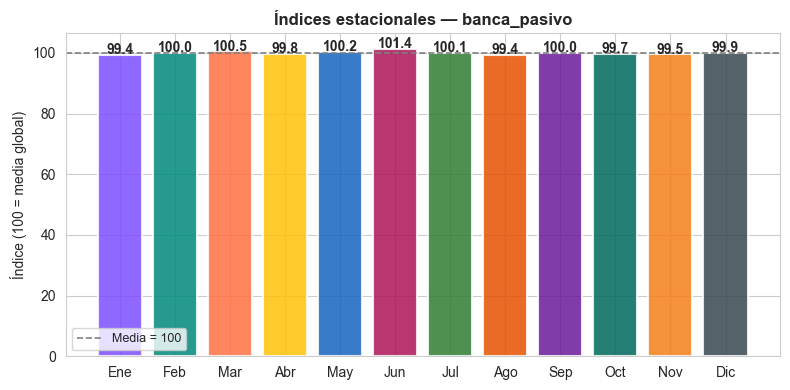

Índices estacionales:
Ene    99.400
Feb   100.000
Mar   100.500
Abr    99.800
May   100.200
Jun   101.400
Jul   100.100
Ago    99.400
Sep   100.000
Oct    99.700
Nov    99.500
Dic    99.900

Periodo con mayor banca_pasivo: Jun (101.4)
Periodo con menor banca_pasivo: Ene (99.4)


In [52]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

La estacionalidad de `ed_pasivo_depositos_total` es marginal: los índices estacionales se mantienen en una banda estrecha entre 99,400 y 101,400 respecto a una media de 100. El máximo corresponde a junio (101,400) y el mínimo a enero, igualado por agosto, ambos en 99,400, de modo que la oscilación estacional no supera el 1,4% por encima ni el 0,6% por debajo de la media global. El resto de meses se sitúa muy próximo a 100: febrero y septiembre en 100,000, marzo en 100,500, abril en 99,800, mayo en 100,200, julio en 100,100, octubre en 99,700, noviembre en 99,500 y diciembre en 99,900. Un patrón de esta amplitud carece de relevancia económica y confirma la ausencia de estacionalidad apreciable ya observada en los boxplots mensuales de la sección anterior y en `ed_activo_total`. La forma estacionaria concreta se resuelve en la fase de feature engineering.

---
## 5. Cambios Periodo a Periodo

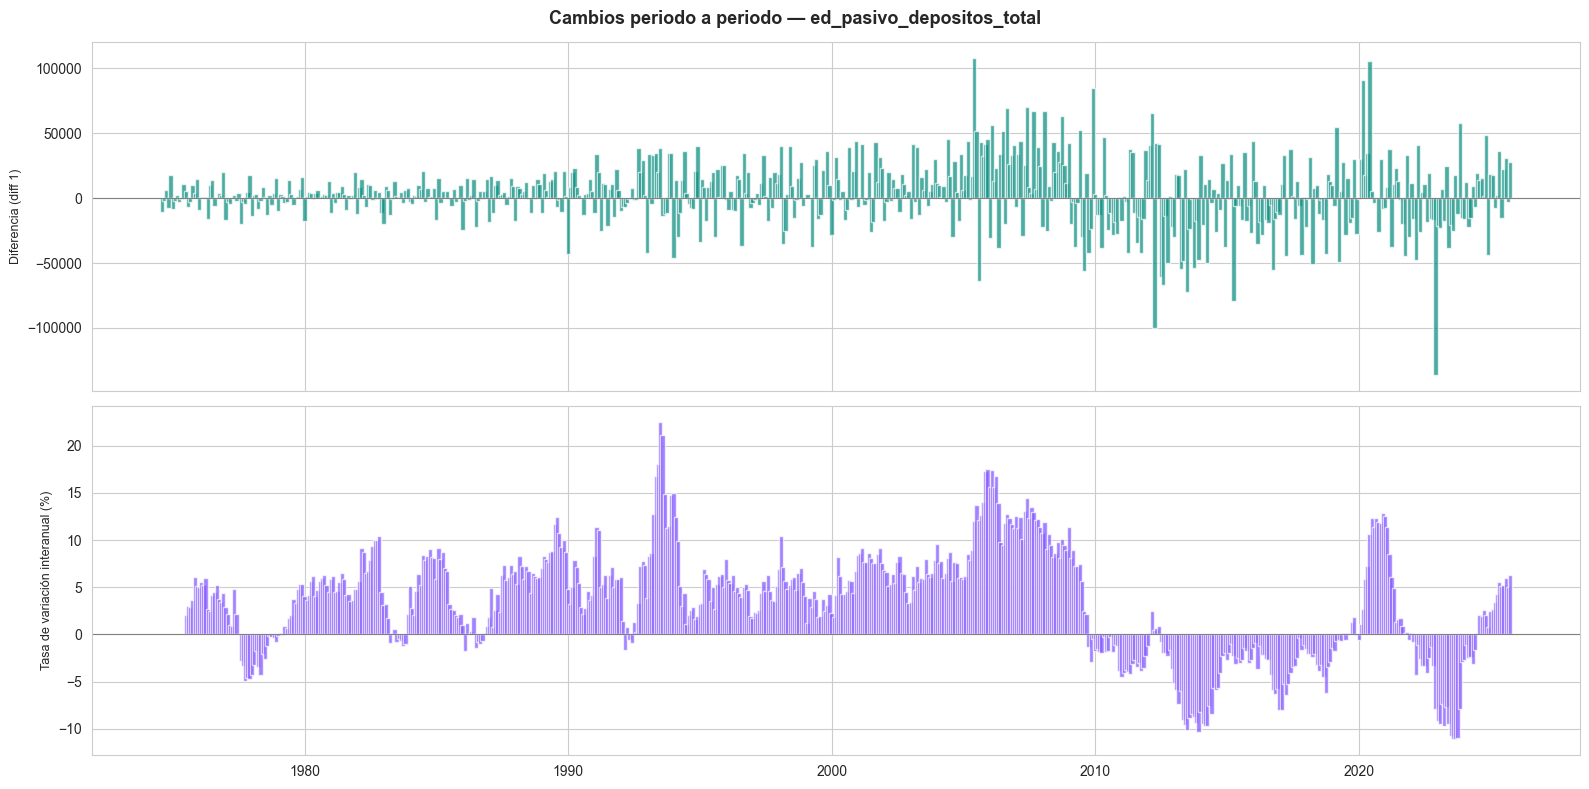

Estadísticas de la variación interanual (%):
count   604.000
mean      3.300
std       5.680
min     -11.120
25%      -0.870
50%       4.060
75%       6.900
max      22.500


In [53]:
diff1 = y.diff(1).dropna()
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100
pct_est = pct_yoy  # alias para tests de estacionariedad y ACF/PACF

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

Las transformaciones de cambio periodo a periodo eliminan la tendencia de nivel pero conservan una dispersión no constante. La primera diferencia oscila en torno a cero sin tendencia visible a lo largo de toda la muestra, con cambios positivos y negativos alternados, pero su amplitud aumenta de forma marcada: de oscilaciones contenidas, por debajo de 20.000 millones en las primeras décadas, pasa a movimientos con picos próximos a 105.000 millones en 2005-2006 y en 2021 y caídas que superan los 100.000 millones, hasta aproximadamente -135.000 en 2023, el valor más extremo de la serie. Esta amplitud creciente es un patrón de heterocedasticidad que se caracteriza en el bloque de estacionariedad.

La tasa de variación interanual se concentra en terreno positivo, con una media de 3,300% y una mediana de 4,060%, pero arrastra una cola negativa relevante: el mínimo es -11,120% y el máximo 22,500%, con una desviación típica de 5,680% sobre 604 observaciones. El rango intercuartílico va de -0,870% a 6,900%, de modo que algo más de una cuarta parte de los periodos registra variación negativa. Que la mediana supere a la media señala una distribución sesgada hacia la izquierda, coherente con los episodios de contracción de los depósitos, prolongados entre 2011 y 2016 y de nuevo en 2023, frente a un crecimiento positivo más frecuente pero de menor intensidad relativa. La forma estacionaria concreta se resuelve en la fase de feature engineering.

---
## 6. Estacionariedad y Autocorrelación

In [54]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'ct'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
    (pct_est, f'{VAR_PRINCIPAL} (var interanual %)', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                                       serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           ed_pasivo_depositos_total (nivel)         ct    -1.122  0.706           False      0.404   0.010             True NO ESTACIONARIA
          ed_pasivo_depositos_total (diff 1)          c    -3.510  0.008            True      0.369   0.091            False    ESTACIONARIA
         ed_pasivo_depositos_total (diff 12)          c    -3.212  0.019            True      0.337   0.100            False    ESTACIONARIA
ed_pasivo_depositos_total (var interanual %)          c    -2.813  0.056           False      0.732   0.011             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  ed_pasivo_depositos_total (nivel)  (KPSS regression='ct')
    ADF  (H₀ = raíz unitaria):  stat=-1.122, p=0.7061 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.404, p=0.0100 (rechaza H₀)
    → N

### Análisis:

Los tests confirman que `ed_pasivo_depositos_total` en nivel es no estacionaria y que las dos diferencias regulares la estacionarizan, mientras que la variación interanual no lo consigue. En nivel, con regresión `ct`, `ADF` no rechaza la hipótesis de raíz unitaria (`stat`=-1,122, `p`=0,706) y `KPSS` rechaza la de estacionariedad (`stat`=0,404, `p`=0,010), convergencia clara en no estacionariedad coherente con la tendencia visible en la serie observada. La primera diferencia es estacionaria por ambos tests: `ADF` rechaza con `stat`=-3,510 y `p`=0,008, y `KPSS` no rechaza con `stat`=0,369 y `p`=0,091, este último marginal por situarse muy cerca del 10%. La diferencia interanual también converge en estacionariedad, con `ADF` `stat`=-3,212 y `p`=0,019 y `KPSS` `stat`=0,337 y `p`=0,100, igualmente marginal en el lado de `KPSS`.

La tasa de variación interanual, en cambio, resulta no estacionaria: `ADF` no rechaza la raíz unitaria (`stat`=-2,813, `p`=0,056, marginal) y `KPSS` rechaza la estacionariedad (`stat`=0,732, `p`=0,011). La convergencia es clara y refleja los regímenes prolongados de variación negativa entre 2011 y 2016 y de nuevo en 2023, junto con los picos positivos de 1993-1994 y 2006-2007, que apartan la serie de una media constante. El contraste con `diff 12`, que sí estacionariza, es consistente: la diferencia interanual en niveles absorbe la persistencia de los regímenes mediante una transformación aditiva, mientras que la variación porcentual amplifica el efecto de los periodos de bajo nivel y mantiene la dependencia temporal.

En conjunto, la serie es no estacionaria en nivel y admite estacionariedad bajo las dos diferencias regulares, con marginalidad de `KPSS` que conviene tener documentada. Este resultado reproduce parcialmente el de `ed_activo_total`, donde las diferencias trimestrales no llegaban a estacionarizar; aquí la frecuencia mensual sí lo logra. La caracterización completa y la elección final de la transformación se resuelven en la fase de feature engineering.

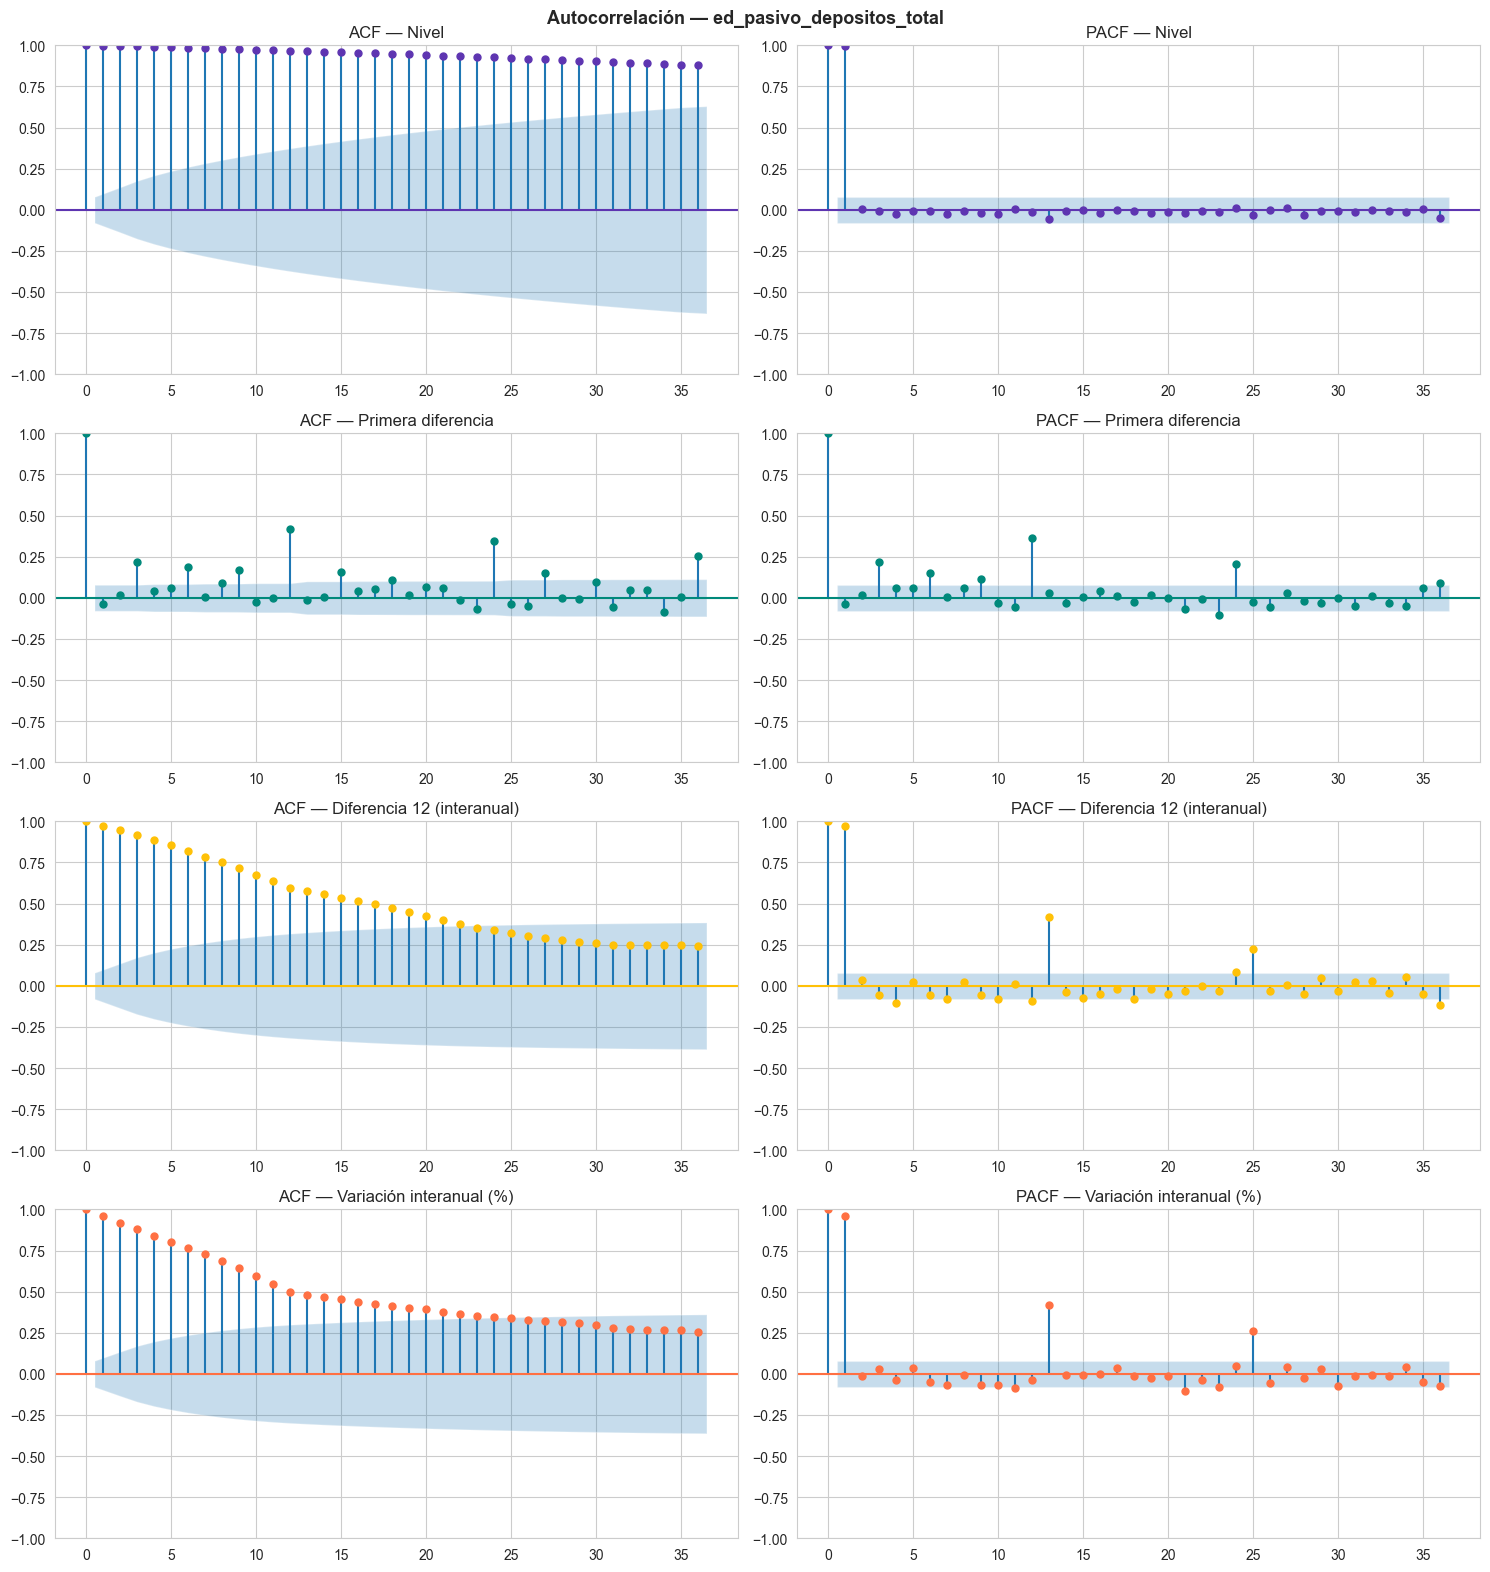

In [55]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FFC107',
         title=f'ACF — Diferencia {PERIODO_ESTACIONAL} (interanual)')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FFC107',
          title=f'PACF — Diferencia {PERIODO_ESTACIONAL} (interanual)', method='ywm')
plot_acf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual (%)')
plot_pacf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual (%)', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

Los correlogramas confirman la lectura de los tests y precisan la dinámica de dependencia temporal en cada transformación. En nivel, la `ACF` decae linealmente desde valores próximos a 1, manteniéndose por encima de 0,85 en los 36 retardos representados, y la `PACF` presenta un único pico cercano a 1 en el retardo 1 con el resto de coeficientes dentro de la banda de no significación. Este patrón es el de una serie no estacionaria con fuerte persistencia, coherente con la convergencia ADF/KPSS en no estacionariedad.

La primera diferencia rompe el decaimiento lento: la `ACF` cae bruscamente y se mantiene mayoritariamente cerca de cero, con picos significativos aislados en los retardos múltiplos de 12, particularmente en 12 (aproximadamente 0,42) y 24 (aproximadamente 0,35), y la `PACF` reproduce el mismo perfil con un pico próximo a 0,37 en el retardo 12. La estructura de dependencia residual es estacional anual, sobre una serie ya estacionarizada en media por la diferencia regular. Este patrón es consistente con la frecuencia mensual de los datos y con el periodo 12 de la descomposición.

La diferencia interanual y la variación interanual porcentual presentan correlogramas casi idénticos. En ambos casos la `ACF` decae despacio desde 1, se mantiene por encima de 0,5 hasta el retardo 10 aproximadamente y aún supera 0,25 en el retardo 36, y la `PACF` muestra un pico dominante próximo a 1 en el retardo 1 acompañado de coeficientes significativos próximos a 0,4 en el retardo 13 y a 0,25 en el retardo 25. El decaimiento lento de la `ACF` es coherente con la no estacionariedad detectada por ADF/KPSS en la variación interanual y con la marginalidad de KPSS sobre `diff 12`: ambas transformaciones reducen la tendencia de nivel pero conservan una persistencia elevada, atribuible a los regímenes prolongados de variación negativa y a la estructura cíclica de los depósitos. La caracterización completa de la dependencia y la elección de la transformación se resuelven en la fase de feature engineering.

### 6.1 Transformación logarítmica

La heterocedasticidad proporcional al nivel documentada en los residuos STL y en la primera diferencia (varianza creciente con el tamaño del balance) motiva probar la transformación logarítmica.

**Justificación MECE del uso de log en este proyecto:**

La transformación logarítmica se aplica únicamente a las series de balance bancario (activo y pasivo), donde la heterocedasticidad es proporcional al nivel y no existe normalización natural por base. En los índices (IPC, IPRI, IPI) la variación interanual porcentual cumple una función análoga al ser equivalente, para variaciones pequeñas, a `diff(log(y), 12)`. Para las series con clusters de volatilidad condicional (tipo de cambio, primera diferencia de la tasa de paro) la log no procede metodológicamente, por lo que la heterocedasticidad queda documentada sin tratamiento en la fase de transformación.

Se evalúan dos transformaciones combinadas:
- `Δ1 log(y)` — crecimiento mensual continuo (aproxima la tasa de variación mensual)
- `Δ12 log(y)` — crecimiento interanual continuo (aproxima la tasa de variación interanual)

In [56]:
log_y = np.log(y[y > 0]).dropna()
log_diff1 = log_y.diff(1).dropna()
log_diff_est = log_y.diff(PERIODO_ESTACIONAL).dropna()

series_test_log = [
    (log_y, f'log({VAR_PRINCIPAL})', 'ct'),
    (log_diff1, f'Δ1 log({VAR_PRINCIPAL})', 'c'),
    (log_diff_est, f'Δ{PERIODO_ESTACIONAL} log({VAR_PRINCIPAL})', 'c'),
]

resultados_log = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_log])

print('Tests de estacionariedad — transformación logarítmica:')
print('=' * 85)
print(resultados_log.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_log.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — transformación logarítmica:
                             serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
    log(ed_pasivo_depositos_total)         ct    -1.395  0.585           False      0.639   0.010             True NO ESTACIONARIA
 Δ1 log(ed_pasivo_depositos_total)          c    -3.893  0.002            True      0.926   0.010             True NO ESTACIONARIA
Δ12 log(ed_pasivo_depositos_total)          c    -2.797  0.059           False      0.763   0.010             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  log(ed_pasivo_depositos_total)  (KPSS regression='ct')
    ADF  stat=-1.395, p=0.5848 (NO rechaza H₀)
    KPSS stat=0.639, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  Δ1 log(ed_pasivo_depositos_total)  (KPSS regression='c')
    ADF  stat=-3.893, p=0.0021 (rechaza H₀)
    KPSS stat=0.926, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  Δ12 log(ed_pas

### Análisis:

La transformación logarítmica no estacionariza `ed_pasivo_depositos_total` en ninguna de sus tres formas y deja al descubierto un cambio estructural en la tasa de crecimiento. Sobre `log(ed_pasivo_depositos_total)` en nivel, con regresión `ct`, los tests convergen en no estacionariedad: `ADF` no rechaza la raíz unitaria (`stat`=-1,395, `p`=0,585) y `KPSS` rechaza la estacionariedad (`stat`=0,639, `p`=0,010). La log preserva por tanto la tendencia del nivel, como cabía esperar de una transformación monótona.

Sobre la primera diferencia del log, los tests son contradictorios: `ADF` rechaza la raíz unitaria con claridad (`stat`=-3,893, `p`=0,002) y `KPSS` rechaza la estacionariedad con el `p` mínimo tabulado (`stat`=0,926, `p`=0,010). La contradicción se interpreta, según el marco metodológico del proyecto, como evidencia de un cambio estructural en la dinámica de crecimiento: la serie es localmente estacionaria a cada lado del punto de ruptura pero no globalmente, porque su media de crecimiento ha cambiado. Este resultado es consistente con el quiebre observable en torno a 2009 en la serie original y reproduce el hallazgo documentado en `ed_activo_total`, lo que confirma la simetría del comportamiento entre activo y pasivo bajo transformación logarítmica.

La diferencia interanual del log tampoco estacionariza: `ADF` no rechaza la raíz unitaria (`stat`=-2,797, `p`=0,059, marginal) y `KPSS` rechaza la estacionariedad (`stat`=0,763, `p`=0,010), convergencia clara en no estacionariedad. La log ha cumplido aquí una función diagnóstica: no produce estacionariedad, pero corrige la heterocedasticidad proporcional al nivel y revela el cambio estructural en la tasa de crecimiento que las transformaciones sobre la serie original no aislaban con la misma nitidez. La caracterización completa y la elección final de la transformación se resuelven en la fase de feature engineering.

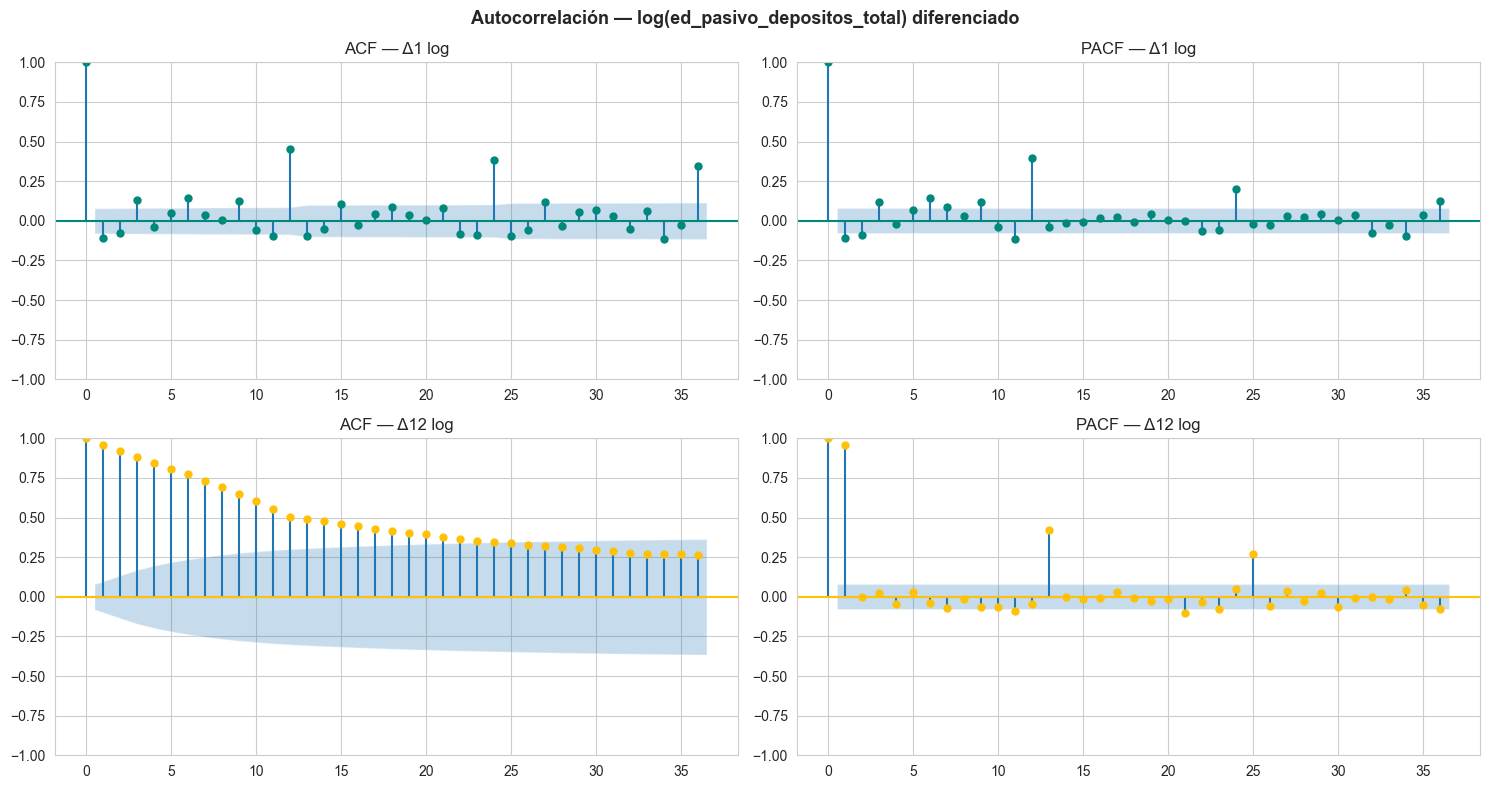

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f'Autocorrelación — log({VAR_PRINCIPAL}) diferenciado', fontsize=13, fontweight='bold')

plot_acf(log_diff1, lags=LAGS_ACF, ax=axes[0, 0], color='#00897B',
         title='ACF — Δ1 log')
plot_pacf(log_diff1, lags=LAGS_ACF, ax=axes[0, 1], color='#00897B',
          title='PACF — Δ1 log', method='ywm')
plot_acf(log_diff_est, lags=LAGS_ACF, ax=axes[1, 0], color='#FFC107',
         title=f'ACF — Δ{PERIODO_ESTACIONAL} log')
plot_pacf(log_diff_est, lags=LAGS_ACF, ax=axes[1, 1], color='#FFC107',
          title=f'PACF — Δ{PERIODO_ESTACIONAL} log', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

Los correlogramas del log diferenciado son coherentes con el resultado de los tests y precisan la estructura de dependencia que queda tras cada transformación. En `Δ1 log`, la `ACF` cae bruscamente desde 1 y se mueve mayoritariamente cerca de cero, con picos significativos aislados en los retardos múltiplos de 12, especialmente en 12 (aproximadamente 0,45), 24 (aproximadamente 0,38) y 36 (aproximadamente 0,33). La `PACF` reproduce el patrón con un pico próximo a 0,40 en el retardo 12 y otro menor próximo a 0,20 en el retardo 24. La estructura de dependencia residual es estacional anual, sobre una serie cuya media de crecimiento varía a lo largo de la muestra; el correlograma describe esta dependencia pero no contradice la conclusión global de no estacionariedad derivada de los tests, que captan el cambio de régimen.

En `Δ12 log`, la `ACF` decae despacio desde 1, se mantiene por encima de 0,5 hasta el retardo 9 aproximadamente y aún supera 0,25 en el retardo 36, manteniéndose fuera de la banda de no significación en todo el rango representado. La `PACF` exhibe un pico dominante próximo a 1 en el retardo 1, un coeficiente significativo cercano a 0,42 en el retardo 13 y otro próximo a 0,28 en el retardo 25. El decaimiento lento de la `ACF` es el patrón característico de una serie no estacionaria con elevada persistencia y replica la lectura de los tests sobre esta misma transformación. La caracterización completa de la dependencia se resuelve en la fase de feature engineering.

### 6.2 Validación a frecuencia trimestral

El bloque previo de tests caracteriza la serie a su frecuencia original, donde la información es más rica. La modelización del paro, sin embargo, opera a frecuencia trimestral (target EPA), por lo que las transformaciones operativas deben validarse a esa misma frecuencia.

Este bloque verifica que las conclusiones sobre estacionariedad se trasladan correctamente a la serie resampleada (por valor de cierre trimestral, coherente con la naturaleza de la variable), sobre la que opera el modelo. Se evalúan las mismas cuatro transformaciones que a frecuencia original:
- nivel trimestral
- `Δ1` trimestral (cambio intertrimestral)
- `Δ4` trimestral (cambio interanual)
- variación interanual porcentual trimestral

In [58]:
# Resampleo a frecuencia trimestral
LAGS_ACF_Q = 16
METODO_Q = 'valor de cierre'
y_q = df[VAR_PRINCIPAL].resample('QS').last().dropna()

diff1_q = y_q.diff(1).dropna()
diff4_q = y_q.diff(4).dropna()
pct_q = ((y_q / y_q.shift(4) - 1) * 100).dropna()

series_test_q = [
    (y_q, f'{VAR_PRINCIPAL} trimestral (nivel)', 'ct'),
    (diff1_q, f'{VAR_PRINCIPAL} trimestral (Δ1)', 'c'),
    (diff4_q, f'{VAR_PRINCIPAL} trimestral (Δ4)', 'c'),
    (pct_q, f'{VAR_PRINCIPAL} trimestral (var interanual %)', 'c'),
]

resultados_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_q])

print(f'Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: {METODO_Q}):')
print('=' * 85)
print(resultados_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: valor de cierre):
                                                  serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           ed_pasivo_depositos_total trimestral (nivel)         ct    -1.209  0.670           False      0.243   0.010             True NO ESTACIONARIA
              ed_pasivo_depositos_total trimestral (Δ1)          c    -2.876  0.048            True      0.229   0.100            False    ESTACIONARIA
              ed_pasivo_depositos_total trimestral (Δ4)          c    -2.589  0.095           False      0.223   0.100            False NO ESTACIONARIA
ed_pasivo_depositos_total trimestral (var interanual %)          c    -2.467  0.124           False      0.497   0.042             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  ed_pasivo_depositos_total trimestral (nivel)  (KPSS regression='ct')
    ADF  stat=-1.209, p=

### Análisis:

La validación en frecuencia trimestral confirma la lectura del bloque mensual y matiza la dinámica de `ed_pasivo_depositos_total` resampleada por valor de cierre. En nivel, con regresión `ct`, los tests convergen en no estacionariedad: `ADF` no rechaza la raíz unitaria (`stat`=-1,209, `p`=0,670) y `KPSS` rechaza la estacionariedad (`stat`=0,243, `p`=0,010). La primera diferencia trimestral resulta estacionaria por ambos tests, con marginalidad: `ADF` rechaza la raíz unitaria con `stat`=-2,876 y `p`=0,048, muy próximo al umbral del 5%, y `KPSS` no rechaza la estacionariedad con `stat`=0,229 y `p`=0,100, el máximo tabulado. La conclusión se sostiene, pero la cercanía a los umbrales conviene quedar documentada.

La diferencia interanual `Δ4` no estacionariza: `ADF` no rechaza la raíz unitaria (`stat`=-2,589, `p`=0,095, marginal) y `KPSS` no rechaza la estacionariedad (`stat`=0,223, `p`=0,100). Las dos no-rechazo simultáneas configuran zona ambigua según el marco metodológico, resuelta del lado de la no estacionariedad por la marginalidad de `ADF` y por el comportamiento de la `ACF` correspondiente. La variación interanual porcentual es no estacionaria con convergencia clara: `ADF` no rechaza la raíz unitaria (`stat`=-2,467, `p`=0,124) y `KPSS` rechaza la estacionariedad (`stat`=0,497, `p`=0,042).

El resultado introduce una diferencia relevante respecto al bloque trimestral de `ed_activo_total`, donde las cuatro transformaciones resultaron no estacionarias. En el pasivo, `Δ1` trimestral sí estacionariza, lo que indica una persistencia algo menor de la serie de depósitos al pasar a la frecuencia trimestral. La caracterización completa y la elección final de la transformación se resuelven en la fase de feature engineering.

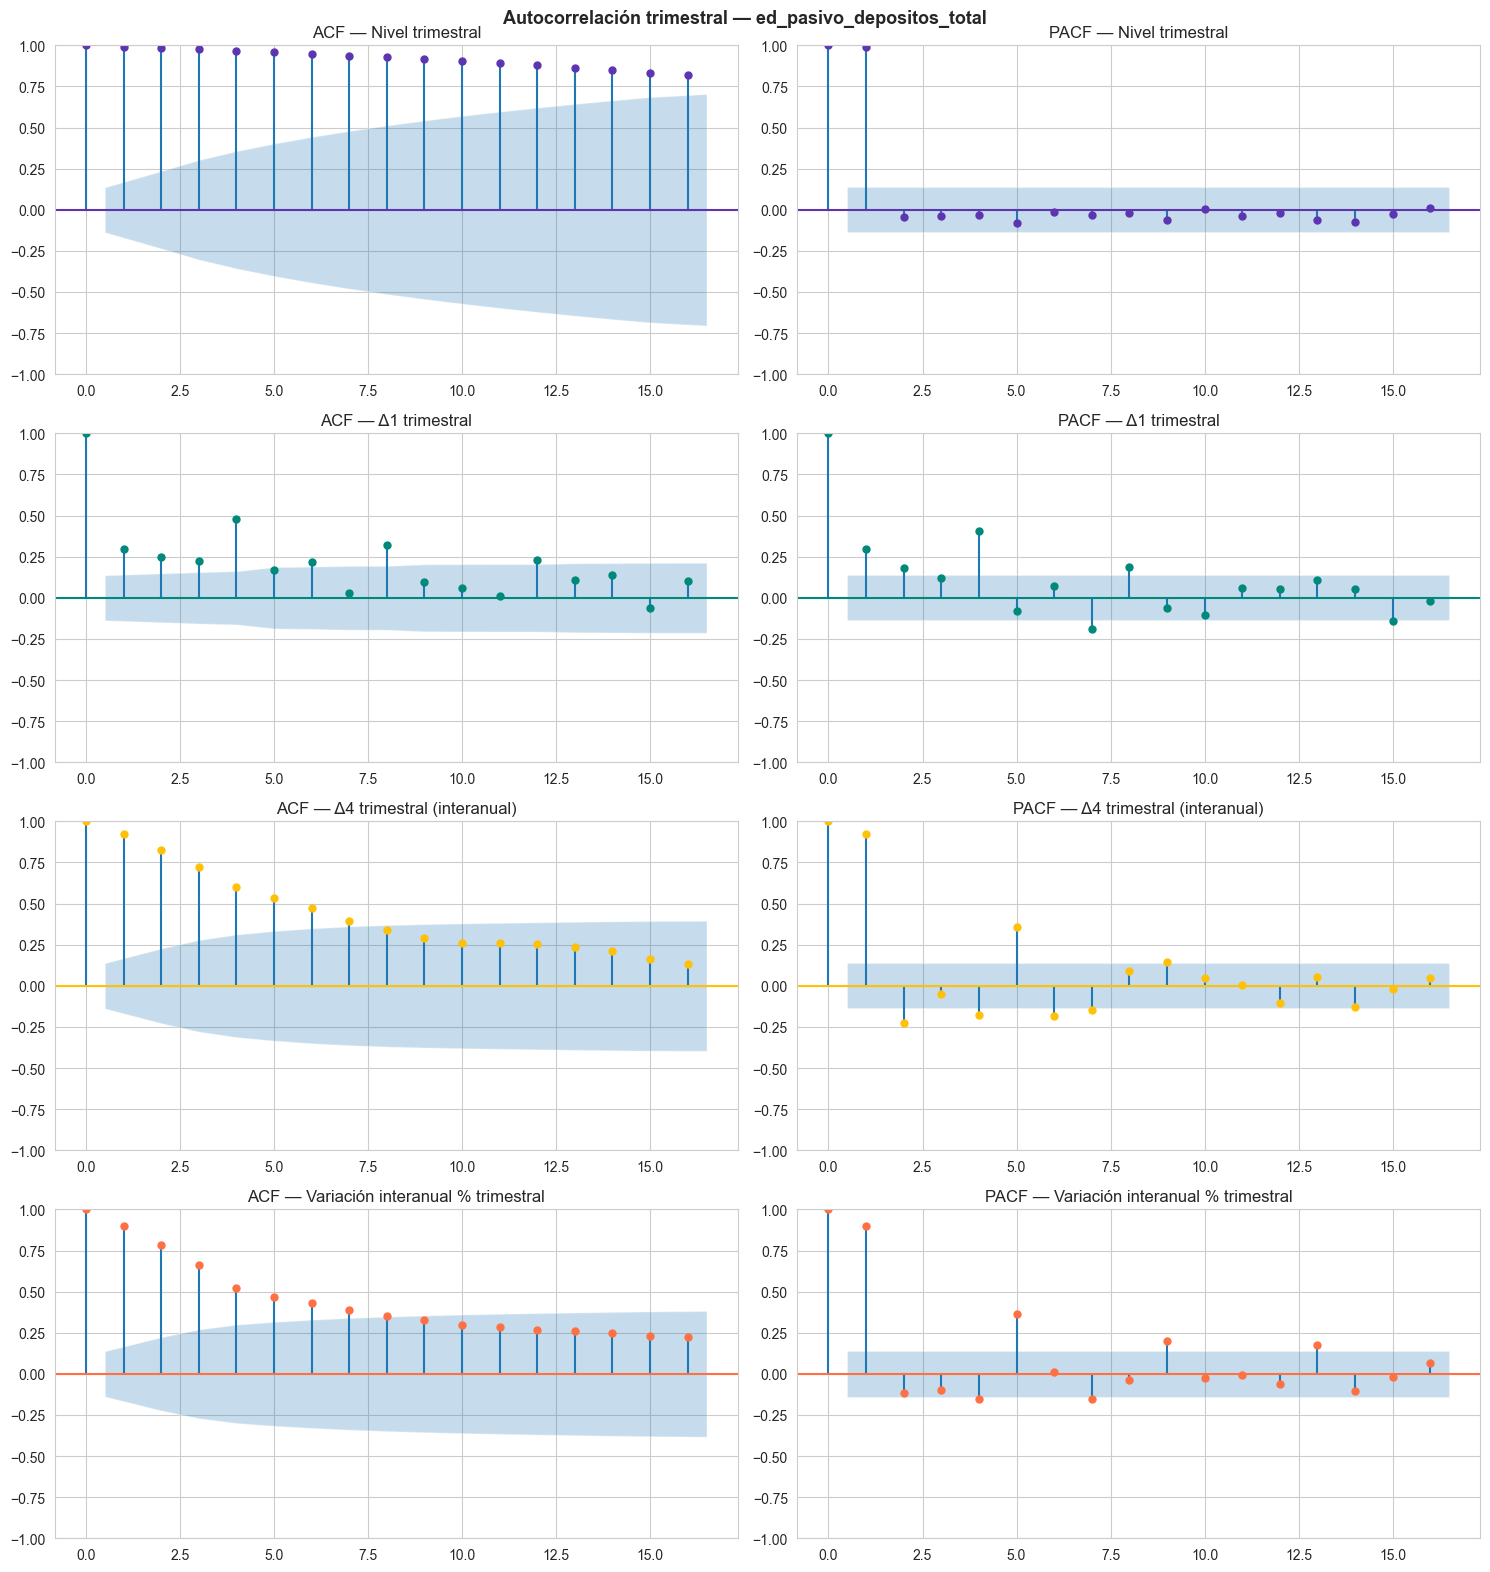

In [59]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación trimestral — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel trimestral')
plot_pacf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel trimestral', method='ywm')
plot_acf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#00897B',
         title='ACF — Δ1 trimestral')
plot_pacf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#00897B',
          title='PACF — Δ1 trimestral', method='ywm')
plot_acf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 0], color='#FFC107',
         title='ACF — Δ4 trimestral (interanual)')
plot_pacf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 1], color='#FFC107',
          title='PACF — Δ4 trimestral (interanual)', method='ywm')
plot_acf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual % trimestral')
plot_pacf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual % trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

Los correlogramas trimestrales son coherentes con los tests y precisan la dinámica de dependencia en cada transformación. En el nivel, la `ACF` decae linealmente desde 1, manteniéndose por encima de 0,80 en los 16 retardos representados, y la `PACF` exhibe un único pico próximo a 1 en el retardo 1 con el resto de coeficientes dentro de la banda. El patrón corresponde a una serie no estacionaria con fuerte persistencia, en línea con la `ACF` mensual del nivel.

En `Δ1` trimestral, la `ACF` cae bruscamente y la mayor parte de los coeficientes queda dentro de la banda, con picos significativos aislados, el mayor próximo a 0,48 en el retardo 4 y otros menores en los retardos 1, 8 y 12, próximos a 0,30. La `PACF` reproduce el perfil con un pico cercano a 0,40 en el retardo 4. La dependencia residual sigue el ciclo anual de la frecuencia trimestral (cuatro periodos por año), sobre una serie ya estacionarizada en media. Este resultado es consistente con la conclusión del test, que sitúa la primera diferencia trimestral en estacionariedad marginal.

En `Δ4` trimestral, la `ACF` decae despacio desde valores próximos a 0,92, se mantiene por encima de 0,50 hasta el retardo 5 y aún supera 0,20 cerca del retardo 14, dentro de la banda en los últimos retardos pero con un perfil claramente persistente. La `PACF` muestra un pico próximo a 0,92 en el retardo 1 y un segundo coeficiente significativo cercano a 0,35 en el retardo 5. La variación interanual porcentual reproduce un perfil análogo, con `ACF` que decae lentamente desde aproximadamente 0,90 y `PACF` con pico próximo a 0,90 en el retardo 1 y coeficiente próximo a 0,37 en el retardo 5. El decaimiento lento de la `ACF` en ambas transformaciones confirma la persistencia detectada por los tests y resuelve la zona ambigua de `Δ4` en favor de la no estacionariedad. La caracterización completa de la dependencia se resuelve en la fase de feature engineering.

In [60]:
# Estacionalidad trimestral reconstruida desde y_q
if len(y_q) >= 8:
    colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107']
    df_box_q = pd.DataFrame({
        'trimestre': y_q.index.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}),
        'valor': y_q.values,
        'fecha': y_q.index.strftime('%Y-%m-%d'),
    })
    df_box_q['trimestre'] = pd.Categorical(df_box_q['trimestre'],
                                            categories=['Q1', 'Q2', 'Q3', 'Q4'], ordered=True)
    fig = px.box(
        df_box_q, x='trimestre', y='valor', color='trimestre',
        hover_data=['fecha'],
        title=f'Estacionalidad trimestral — {VAR_PRINCIPAL}',
        labels={'valor': UNIDADES, 'trimestre': 'Trimestre'},
        color_discrete_sequence=colores_bp,
    )
    fig.update_layout(showlegend=False, height=420)
    fig.show()

    medias_q = y_q.groupby(y_q.index.quarter).mean()
    cv_trimestral = medias_q.std() / medias_q.mean() * 100 if medias_q.mean() != 0 else 0
    medias_dict = {k: round(float(v), 3) for k, v in medias_q.items()}
    print('Media por trimestre:', medias_dict)
    estac = '(estacionalidad apreciable)' if cv_trimestral > 5 else '(estacionalidad leve)'
    print(f'CV entre trimestres: {cv_trimestral:.2f}% {estac}')

Media por trimestre: {1: 1582318.133, 2: 1596368.612, 3: 1574009.298, 4: 1586624.103}
CV entre trimestres: 0.59% (estacionalidad leve)


### Análisis:

La estacionalidad trimestral de `ed_pasivo_depositos_total` es marginal, con un coeficiente de variación entre trimestres del 0,59%. Las medias por trimestre se sitúan en 1.582.318,133 millones en Q1, 1.596.368,612 en Q2, 1.574.009,298 en Q3 y 1.586.624,103 en Q4, todas en una banda estrecha en torno a 1,58 billones EUR constantes de 2025, con Q2 ligeramente por encima y Q3 ligeramente por debajo. Los boxplots reflejan esa equivalencia: medianas próximas a 1,45 billones en los cuatro trimestres, rangos intercuartílicos superpuestos que cubren aproximadamente de 0,68 a 2,35 billones y bigotes que abarcan prácticamente el recorrido completo de la serie. Ningún trimestre presenta un nivel sistemáticamente superior ni una dispersión diferenciada. El resultado replica la ausencia de estacionalidad detectada en la frecuencia mensual, en los índices estacionales y en `ed_activo_total`, y confirma que la dinámica de la serie está dominada por la tendencia y por los regímenes de nivel, no por un patrón estacional. La caracterización de la forma estacionaria se resuelve en la fase de feature engineering.

### 6.3 Transformación logarítmica a frecuencia trimestral

La transformación logarítmica, evaluada antes a frecuencia mensual como respuesta a la heterocedasticidad proporcional al nivel, se valida también a la frecuencia trimestral sobre la que opera el modelo, en coherencia con el resto de transformaciones de este bloque.

In [61]:
log_y_q = np.log(y_q[y_q > 0]).dropna()
log_diff1_q = log_y_q.diff(1).dropna()
log_diff4_q = log_y_q.diff(4).dropna()

series_test_log_q = [
    (log_y_q, f'log({VAR_PRINCIPAL}) trimestral', 'ct'),
    (log_diff1_q, f'Δ1 log({VAR_PRINCIPAL}) trimestral', 'c'),
    (log_diff4_q, f'Δ4 log({VAR_PRINCIPAL}) trimestral', 'c'),
]

resultados_log_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_log_q])

print('Tests de estacionariedad — log trimestral:')
print('=' * 85)
print(resultados_log_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_log_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — log trimestral:
                                       serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
   log(ed_pasivo_depositos_total) trimestral         ct    -1.371  0.596           False      0.381   0.010             True NO ESTACIONARIA
Δ1 log(ed_pasivo_depositos_total) trimestral          c    -3.000  0.035            True      0.647   0.018             True NO ESTACIONARIA
Δ4 log(ed_pasivo_depositos_total) trimestral          c    -2.452  0.128           False      0.517   0.038             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  log(ed_pasivo_depositos_total) trimestral  (KPSS regression='ct')
    ADF  stat=-1.371, p=0.5963 (NO rechaza H₀)
    KPSS stat=0.381, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  Δ1 log(ed_pasivo_depositos_total) trimestral  (KPSS regression='c')
    ADF  stat=-3.000, p=0.0349 (rechaza H₀)
    KPSS stat=0.647, p=0.0183 (r

### Análisis:

La transformación logarítmica no estacionariza `ed_pasivo_depositos_total` en frecuencia trimestral en ninguna de sus formas y reproduce el diagnóstico de cambio estructural ya detectado en el bloque mensual. Sobre `log(ed_pasivo_depositos_total)` en nivel, con regresión `ct`, los tests convergen en no estacionariedad: `ADF` no rechaza la raíz unitaria (`stat`=-1,371, `p`=0,596) y `KPSS` rechaza la estacionariedad (`stat`=0,381, `p`=0,010). La log preserva por tanto la tendencia del nivel también a esta frecuencia.

Sobre la primera diferencia del log trimestral, los tests son contradictorios: `ADF` rechaza la raíz unitaria con `stat`=-3,000 y `p`=0,035, y `KPSS` rechaza la estacionariedad con `stat`=0,647 y `p`=0,018. La contradicción se interpreta, según el marco metodológico del proyecto, como evidencia de un cambio estructural en la dinámica de crecimiento: la serie es localmente estacionaria a cada lado del punto de ruptura pero no globalmente, porque su media de crecimiento ha cambiado. Este resultado replica exactamente la contradicción detectada sobre `Δ1 log` mensual y consolida el diagnóstico de cambio en la tasa de crecimiento en torno a 2009.

La diferencia interanual del log es no estacionaria con convergencia clara: `ADF` no rechaza la raíz unitaria (`stat`=-2,452, `p`=0,128) y `KPSS` rechaza la estacionariedad (`stat`=0,517, `p`=0,038). El bloque trimestral del log confirma así dos hallazgos: la log no produce estacionariedad sobre esta serie en ninguna frecuencia, y aísla un cambio estructural en la tasa de crecimiento que las transformaciones sobre la serie original no revelaban con la misma nitidez. El paralelismo con `ed_activo_total` se sostiene en las dos frecuencias. La caracterización completa y la elección final de la transformación se resuelven en la fase de feature engineering.

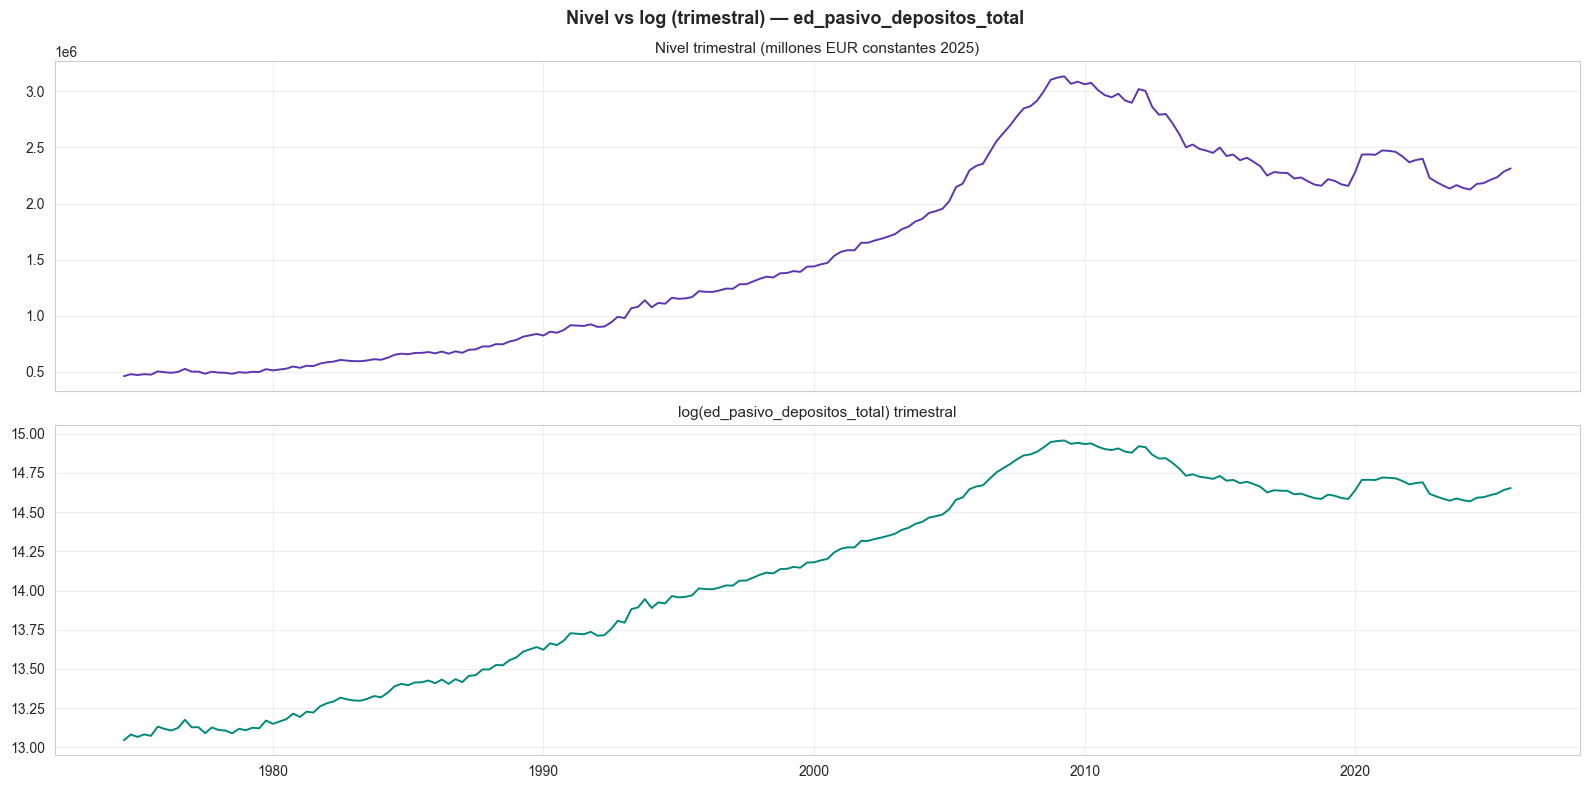

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Nivel vs log (trimestral) — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].plot(y_q.index, y_q, color=COLOR_PRINCIPAL, lw=1.4)
axes[0].set_title(f'Nivel trimestral ({UNIDADES})', fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(log_y_q.index, log_y_q, color='#00897B', lw=1.4)
axes[1].set_title(f'log({VAR_PRINCIPAL}) trimestral', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis:

La transformación logarítmica sobre la serie trimestral preserva la trayectoria del nivel y comprime su escala, sin alterar la conclusión de no estacionariedad. El nivel recorre de aproximadamente 0,46 billones EUR constantes de 2025 a comienzos de la muestra hasta el máximo en el entorno de 3,1 billones alrededor de 2009, con descenso posterior que estabiliza la serie cerca de 2,2-2,3 billones en la última década. La transformación log reproduce el mismo perfil sobre una escala de aproximadamente 13,05 a 14,95, con el máximo igualmente en 2009 y descenso posterior. La log comprime la fase inicial de crecimiento exponencial y deja la dinámica del periodo 2005-2025 con una forma muy parecida a la del nivel, lo que sugiere que el crecimiento de la fase final no fue exponencial sino más próximo a lineal. La forma estacionaria concreta se resuelve en la fase de feature engineering.

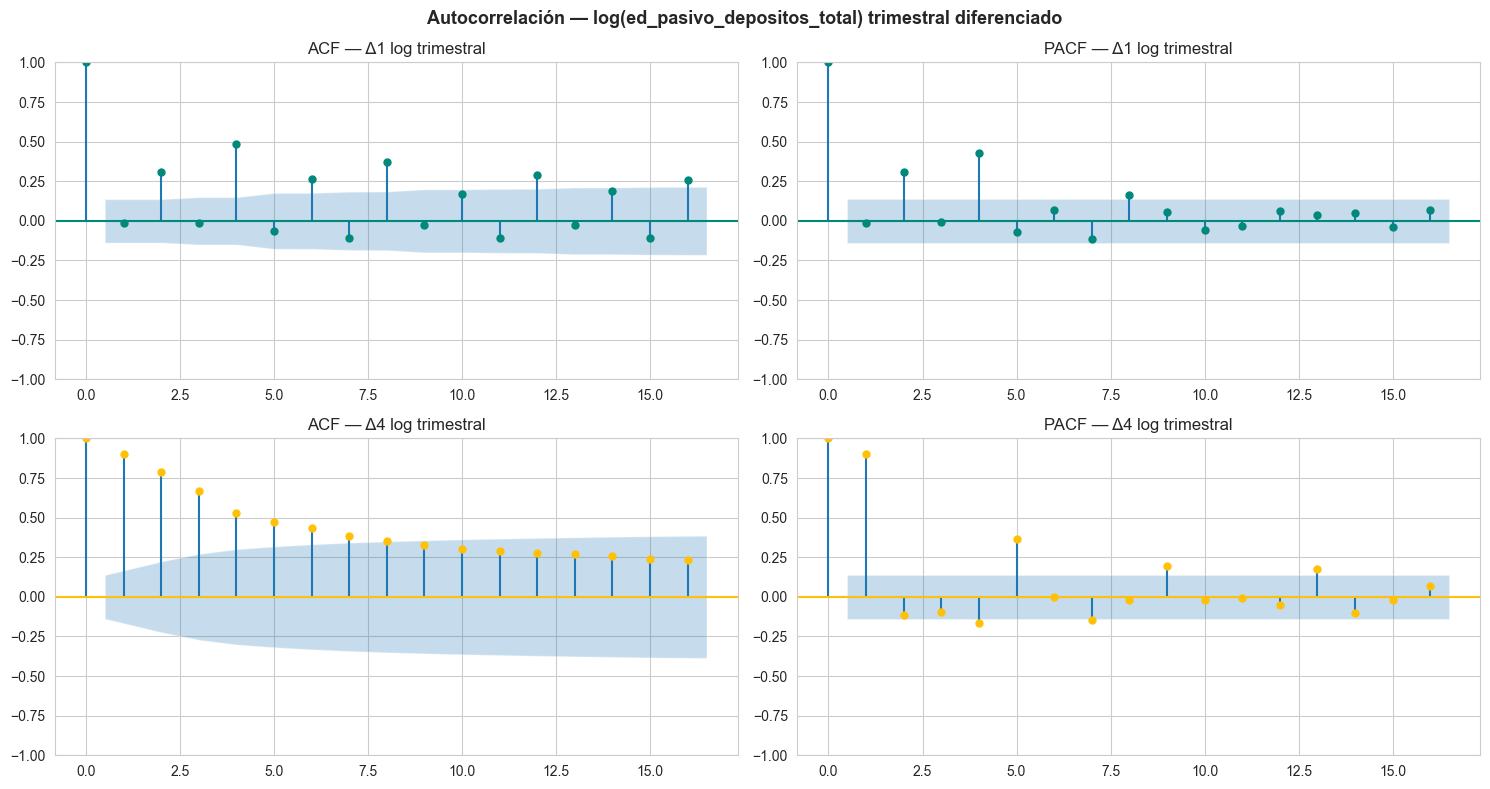

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f'Autocorrelación — log({VAR_PRINCIPAL}) trimestral diferenciado', fontsize=13, fontweight='bold')

plot_acf(log_diff1_q, lags=LAGS_ACF_Q, ax=axes[0, 0], color='#00897B',
         title='ACF — Δ1 log trimestral')
plot_pacf(log_diff1_q, lags=LAGS_ACF_Q, ax=axes[0, 1], color='#00897B',
          title='PACF — Δ1 log trimestral', method='ywm')
plot_acf(log_diff4_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#FFC107',
         title='ACF — Δ4 log trimestral')
plot_pacf(log_diff4_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#FFC107',
          title='PACF — Δ4 log trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

Los correlogramas confirman la lectura de los tests y precisan la dependencia residual tras cada transformación logarítmica. En `Δ1 log` trimestral, la `ACF` cae bruscamente y la mayor parte de los coeficientes queda dentro de la banda de no significación, con picos significativos aislados en los múltiplos de 4: el mayor próximo a 0,48 en el retardo 4, y otros menores próximos a 0,37 en el retardo 8 y a 0,30 en el retardo 12. La `PACF` reproduce el perfil con un pico cercano a 0,42 en el retardo 4. La dependencia residual sigue el ciclo anual de la frecuencia trimestral.

En `Δ4 log` trimestral, la `ACF` decae despacio desde valores próximos a 0,90, se mantiene por encima de 0,50 hasta el retardo 4 y aún supera 0,25 en el retardo 15, con coeficientes fuera de la banda hasta los últimos retardos. La `PACF` muestra un pico próximo a 0,90 en el retardo 1 y un segundo coeficiente significativo cercano a 0,37 en el retardo 5. El decaimiento lento de la `ACF` es coherente con la conclusión de no estacionariedad sobre esta transformación y replica el patrón observado en `Δ4` trimestral sobre la serie sin logaritmo. La caracterización completa de la dependencia se resuelve en la fase de feature engineering.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [64]:
df_der = pd.DataFrame(index=df.index)

# Crecimiento interanual de depósitos totales
df_der['crecimiento_depositos_yoy'] = df[VAR_PRINCIPAL].pct_change(12) * 100

# Composición por sector sobre depósitos totales
for comp in ['ed_pasivo_depositos_esp', 'ed_pasivo_sector_privado',
             'ed_pasivo_deposito_resto_mundo', 'ed_pasivo_depositos_sector_publico']:
    if comp in df.columns:
        df_der[f'{comp}_share'] = df[comp] / df[VAR_PRINCIPAL] * 100

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (5):


,crecimiento_depositos_yoy,ed_pasivo_depositos_esp_share,ed_pasivo_sector_privado_share,ed_pasivo_deposito_resto_mundo_share,ed_pasivo_depositos_sector_publico_share
count,604.000,616.000,616.000,616.000,616.000
mean,3.304,15.570,65.592,15.925,2.913
std,5.684,4.809,6.729,5.857,1.432
min,-11.119,3.888,53.444,5.741,0.754
25%,-0.871,12.447,59.537,11.667,2.029
50%,4.055,15.012,66.314,14.344,2.946
75%,6.895,18.067,69.257,21.059,3.719
max,22.498,27.604,81.844,28.030,8.885


### Análisis:

Los estadísticos descriptivos de las cinco variables derivadas perfilan la composición del pasivo y la dinámica de crecimiento, todas no estacionarias en nivel a juzgar por la trayectoria que presentan en el bloque gráfico. `crecimiento_depositos_yoy` se calcula sobre 604 observaciones, doce menos que las 616 de las shares al perder el primer año por la transformación interanual, y presenta media 3,304%, mediana 4,055%, desviación típica 5,684%, mínimo -11,119% y máximo 22,498%, con rango intercuartílico de -0,871% a 6,895%; la mediana por encima de la media confirma el sesgo a la izquierda introducido por los episodios prolongados de variación negativa.

La composición sectorial está dominada por el sector privado: `ed_pasivo_sector_privado_share` se mueve entre 53,444% y 81,844% con media 65,592% y mediana 66,314% sobre 616 observaciones, banda muy estrecha en comparación con las componentes menores. `ed_pasivo_depositos_esp_share` recorre de 3,888% a 27,604% con media 15,570% y mediana 15,012%, y `ed_pasivo_deposito_resto_mundo_share` de 5,741% a 28,030% con media 15,925% y mediana 14,344%, ambas con dispersión relativa elevada. `ed_pasivo_depositos_sector_publico_share` es marginal pero con cola derecha pronunciada: media 2,913%, mediana 2,946%, mínimo 0,754% y máximo 8,885%, con el percentil 75 en 3,719%, lo que indica que el máximo se alcanza fuera del rango habitual. La caracterización de la forma estacionaria de cada derivada se aborda en los bloques siguientes.

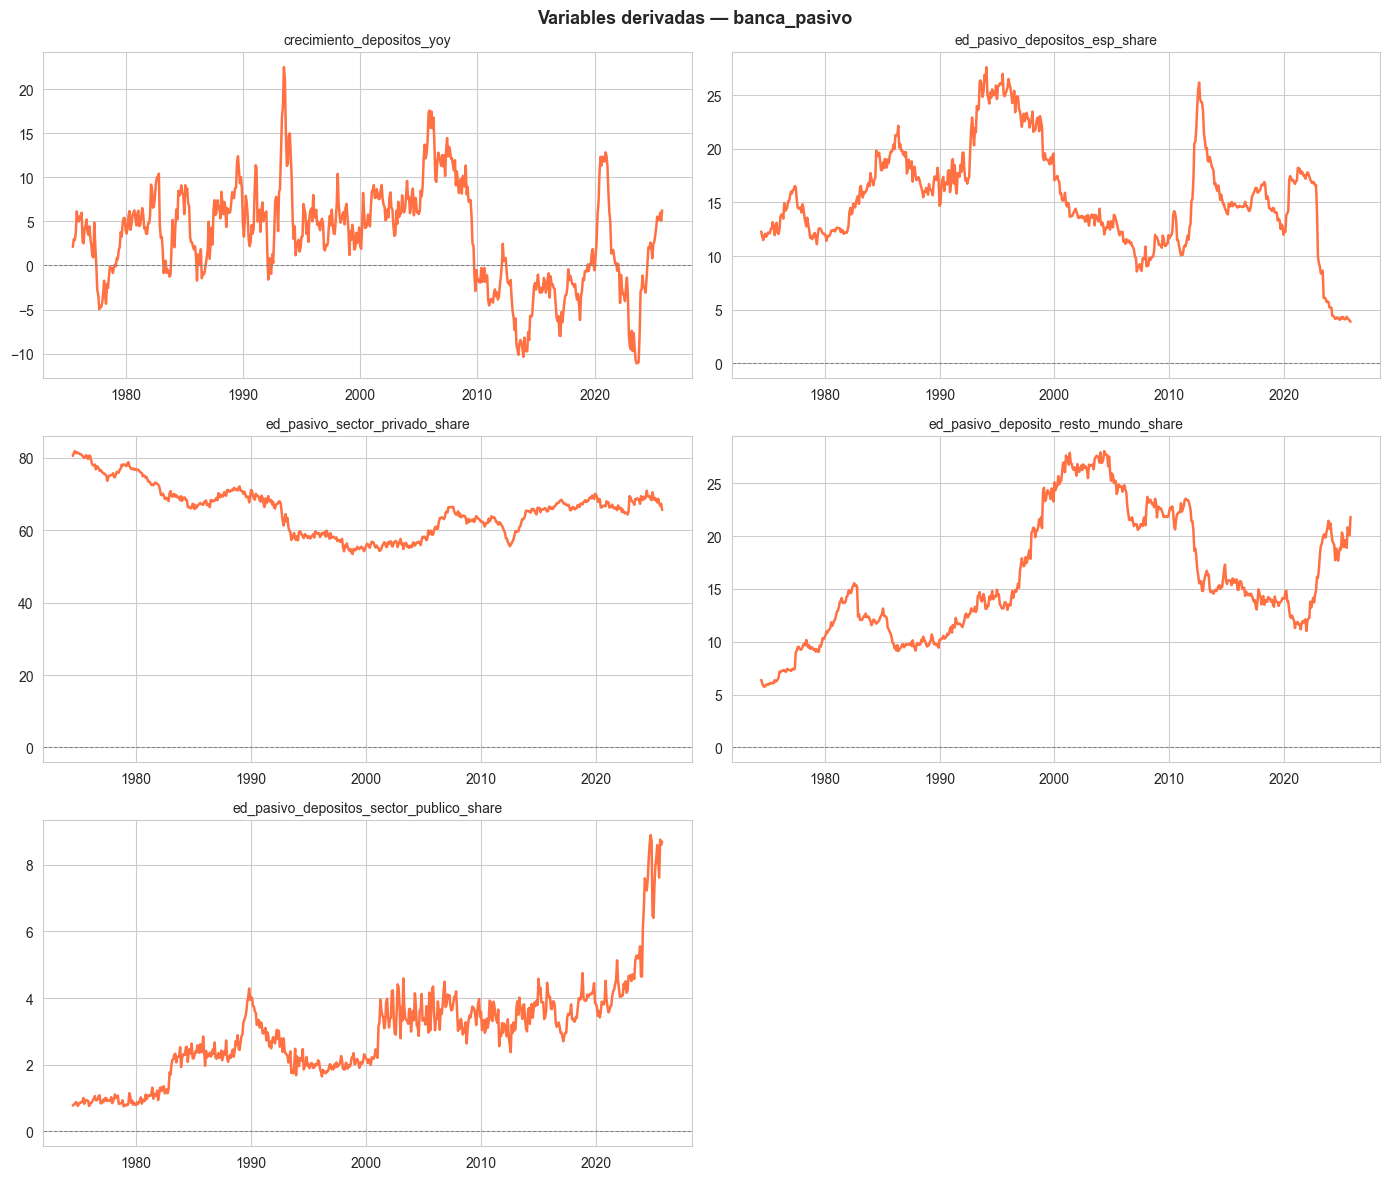

In [65]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

Las trayectorias de las cinco derivadas combinan dinámicas cíclicas, recomposiciones estructurales del pasivo y un cambio de régimen reciente en una de las shares. `crecimiento_depositos_yoy` reproduce el perfil ya descrito en el bloque de cambios periodo a periodo, con alternancia de regímenes positivos y negativos, máximo cercano al 22% en 1993-1994, tramo por encima del 15% en 2006-2007, contracción prolongada entre 2011 y 2016 que se aproxima al -10%, mínimo en 2023 próximo al -11% y repunte cercano al 12% en 2021.

`ed_pasivo_sector_privado_share` describe una trayectoria oscilante en torno a 60-70% durante toda la muestra, con descenso desde aproximadamente 80% al inicio hasta valores cercanos al 55% entre 1995 y 2000, repunte hasta el entorno del 70% en 2010 y estabilidad posterior en torno al 65-70%. `ed_pasivo_depositos_esp_share` recorre la banda 8-27% con dos máximos relativos próximos al 27% en 1995 y al 26% en 2012, descenso posterior a niveles cercanos al 4-5% al final de la muestra, el nivel más bajo del recorrido. `ed_pasivo_deposito_resto_mundo_share` muestra una dinámica complementaria: arranca cerca del 6%, sube hasta aproximadamente 27% en 2003-2005, desciende a la banda 12-15% durante la década siguiente y vuelve a repuntar hasta valores próximos al 22% en los últimos trimestres.

`ed_pasivo_depositos_sector_publico_share` tiene un perfil distinto a las demás: se mantiene por debajo del 2% hasta finales de los setenta, oscila entre 2% y 4% durante las décadas siguientes y presenta un repunte marcado en los últimos años de la muestra que la lleva a valores próximos al 9%, su máximo. Este último tramo configura un cambio de régimen reciente en el peso de los depósitos del sector público sobre el pasivo total; la asociación con factores específicos del periodo queda como hipótesis no verificada. La caracterización de la forma estacionaria de cada derivada se resuelve en la fase de feature engineering.

In [66]:
# ── Guardar dataset enriquecido (trimestral) ───────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]

# Remuestrear a frecuencia trimestral (last para saldos/stocks bancarios)
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'float32']]
df_trimestral = df[cols_num].resample('QS').last()
df_trimestral = df_trimestral.dropna(how='all')

# Guardar CSV trimestral
ruta_q = ruta.parent / (ruta.stem + '_trimestral.csv')
df_trimestral.to_csv(ruta_q)
print(f'CSV trimestral guardado: {ruta_q.name}')
print(f'  Columnas: {len(df_trimestral.columns)}')
print(f'  Rango: {df_trimestral.index.min().date()} — {df_trimestral.index.max().date()}')
print(f'  Observaciones: {len(df_trimestral)} trimestres')


CSV trimestral guardado: ed_pasivo_historico_1962_2026_trimestral.csv
  Columnas: 17
  Rango: 1974-07-01 — 2025-10-01
  Observaciones: 206 trimestres


---
## 8. Tabla Resumen

In [67]:
est_q_nivel = resultados_q[resultados_q['serie'].str.contains('nivel')]['conclusion'].values[0]
est_q_d1 = resultados_q[resultados_q['serie'].str.contains(r'\(Δ1\)')]['conclusion'].values[0]
est_q_d4 = resultados_q[resultados_q['serie'].str.contains(r'\(Δ4\)')]['conclusion'].values[0]
est_q_pct = resultados_q[resultados_q['serie'].str.contains('var interanual')]['conclusion'].values[0]
est_q_logd1 = resultados_log_q[resultados_log_q['serie'].str.contains('Δ1 log')]['conclusion'].values[0]
est_q_logd4 = resultados_log_q[resultados_log_q['serie'].str.contains('Δ4 log')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

q1q, q3q = y_q.quantile(0.25), y_q.quantile(0.75)
iqr_q = q3q - q1q
outliers_q = y_q[(y_q < q1q - 1.5 * iqr_q) | (y_q > q3q + 1.5 * iqr_q)]

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            f'trimestral (resampleo: {METODO_Q})',
    'N obs original':        f"{len(y.dropna())} ({DATASET_CONFIG['frecuencia_original']})",
    'Rango':                 f'{y_q.index.min().date()} — {y_q.index.max().date()}',
    'N obs':                 len(y_q.dropna()),
    'Media':                 y_q.mean().round(2),
    'Mediana':               y_q.median().round(2),
    'Std':                   y_q.std().round(2),
    'CV (%)':                (y_q.std() / y_q.mean() * 100).round(1),
    'Mín (fecha)':           f'{y_q.min():.1f} ({y_q.idxmin().date()})',
    'Máx (fecha)':           f'{y_q.max():.1f} ({y_q.idxmax().date()})',
    'Outliers IQR':          len(outliers_q),
    '% faltantes (original)': f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':            est_q_nivel,
    'Estacionaria (Δ1)':               est_q_d1,
    'Estacionaria (Δ4)':               est_q_d4,
    'Estacionaria (var interanual %)': est_q_pct,
    'Estacionaria (Δ1 log)':           est_q_logd1,
    'Estacionaria (Δ4 log)':           est_q_logd4,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN (frecuencia trimestral)')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN (frecuencia trimestral)
                                                                   Valor
Dataset                                                     banca_pasivo
Variable                                       ed_pasivo_depositos_total
Frecuencia                       trimestral (resampleo: valor de cierre)
N obs original                                             616 (mensual)
Rango                                            1974-07-01 — 2025-10-01
N obs                                                                206
Media                                                        1584786.220
Mediana                                                      1448846.390
Std                                                           858601.420
CV (%)                                                            54.200
Mín (fecha)                                        462638.2 (1974-07-01)
Máx (fecha)                                       3133081.1 (2009-04-01)
Outliers IQR 

### Análisis:

`ed_pasivo_depositos_total` queda caracterizada como una serie no estacionaria de stock contable con persistencia elevada y un cambio estructural en la tasa de crecimiento en el entorno de 2009. La muestra cubre 616 observaciones mensuales entre 1974-07 y 2025-10, sin valores faltantes y sin outliers por IQR, con resampleo a frecuencia trimestral por valor de cierre que produce 206 observaciones. Sobre la serie trimestral, la media es 1.584.786,220 millones EUR constantes de 2025 y la mediana 1.448.846,390, con desviación típica 858.601,420 y coeficiente de variación 54,2%, valores que reflejan la amplitud del recorrido entre el mínimo de 462.638,2 millones en 1974-Q3 y el máximo de 3.133.081,1 millones en 2009-Q2. El periodo estacional más alto es junio y el más bajo enero, con índices estacionales y CV trimestral entre cajas muy próximos a 100 y por debajo del 1%, lo que descarta estacionalidad relevante en ambas frecuencias.

El diagnóstico de estacionariedad converge en seis pruebas. La serie en nivel es no estacionaria a ambas frecuencias. `Δ1` trimestral resulta estacionaria por ADF y KPSS, con marginalidad en los dos tests (`ADF p`=0,048, `KPSS p`=0,100), mientras que `Δ4` trimestral, la variación interanual porcentual y las dos diferencias del log trimestral son no estacionarias. La contradicción ADF/KPSS sobre `Δ1 log`, replicada en frecuencia mensual y trimestral, se interpreta como evidencia de cambio estructural en la dinámica de crecimiento alrededor de 2009. La log no produce estacionariedad pero corrige la heterocedasticidad proporcional al nivel y opera como herramienta diagnóstica, en paralelo a lo observado en `ed_activo_total`.

La forma con la que la serie entra en el análisis cruzado con `tasa_paro_ambos_sexos_total` es `Δ1` trimestral, la única transformación que pasa los dos tests a la frecuencia de modelado, con la marginalidad reseñada y la advertencia del cambio estructural en el periodo 2008-2009. La elección final de la forma con la que la serie entrará en cada modelo se resuelve en la fase de feature engineering.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Banca Pasivo** y el desempleo (EPA, desde 1976Q3).

In [68]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('last').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = df_resampled[VAR_PRINCIPAL].diff(1)                    #
main_s9_label = f'Δ1 {VAR_PRINCIPAL}'                            #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Δ1 ed_pasivo_depositos_total
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 198


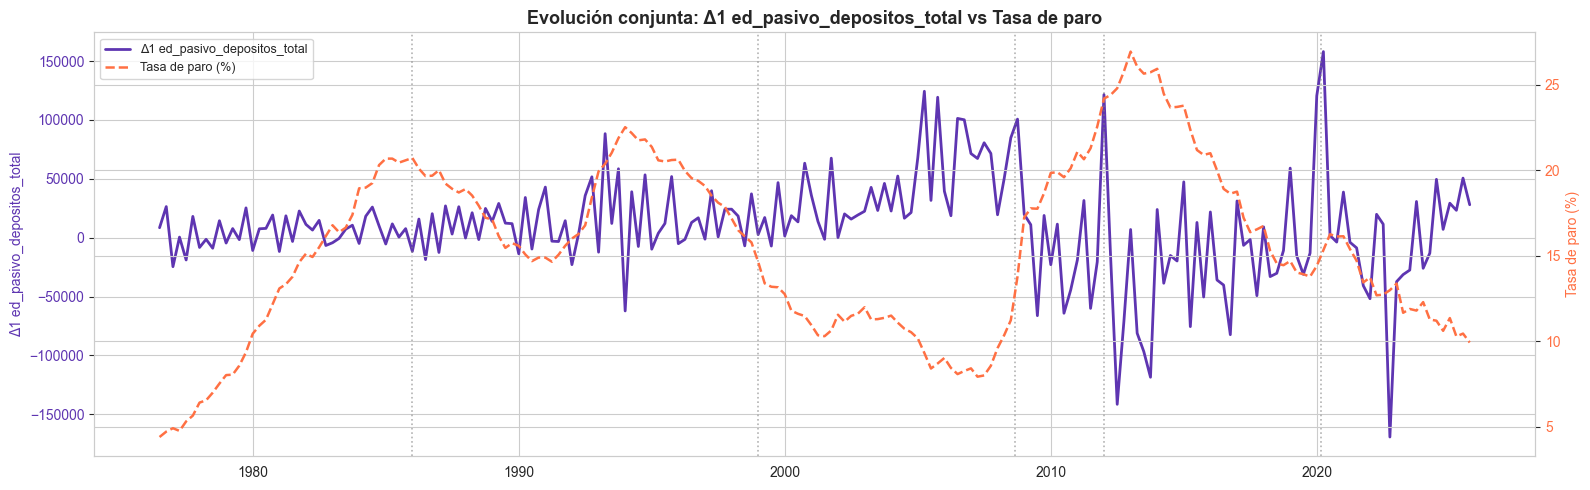

In [69]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

Δ1 de `ed_pasivo_depositos_total` y `tasa_paro_ambos_sexos_total` muestran una relación inversa débil y no contemporánea. La primera diferencia oscila en torno a cero durante toda la muestra con amplitud creciente, contenida por debajo de 25.000 millones en las primeras décadas, y se expande hasta picos próximos a 125.000 millones en 2005-2006 y 160.000 millones en 2020, y caídas que alcanzan aproximadamente -145.000 millones en 2012 y -170.000 millones en 2023. La tasa de paro recorre desde valores cercanos al 5% a mediados de los setenta hasta máximos próximos al 22% en 1994 y al 27% en 2013, con un mínimo intermedio cercano al 8% en 2007 y una bajada hasta aproximadamente el 10% al final de la muestra. Los tramos de mayor crecimiento de los depósitos, en 2005-2007 y 2020, coinciden con paro descendente o estabilizado en niveles bajos, mientras que las contracciones más profundas, en 2012 y 2023, se sitúan en periodos de paro elevado o de inflexión. La amplitud creciente de Δ1 a lo largo de la muestra implica que la relación lineal no es homogénea en el tiempo, característica que se cuantifica en los bloques siguientes. La caracterización completa se resuelve en la fase de feature engineering.

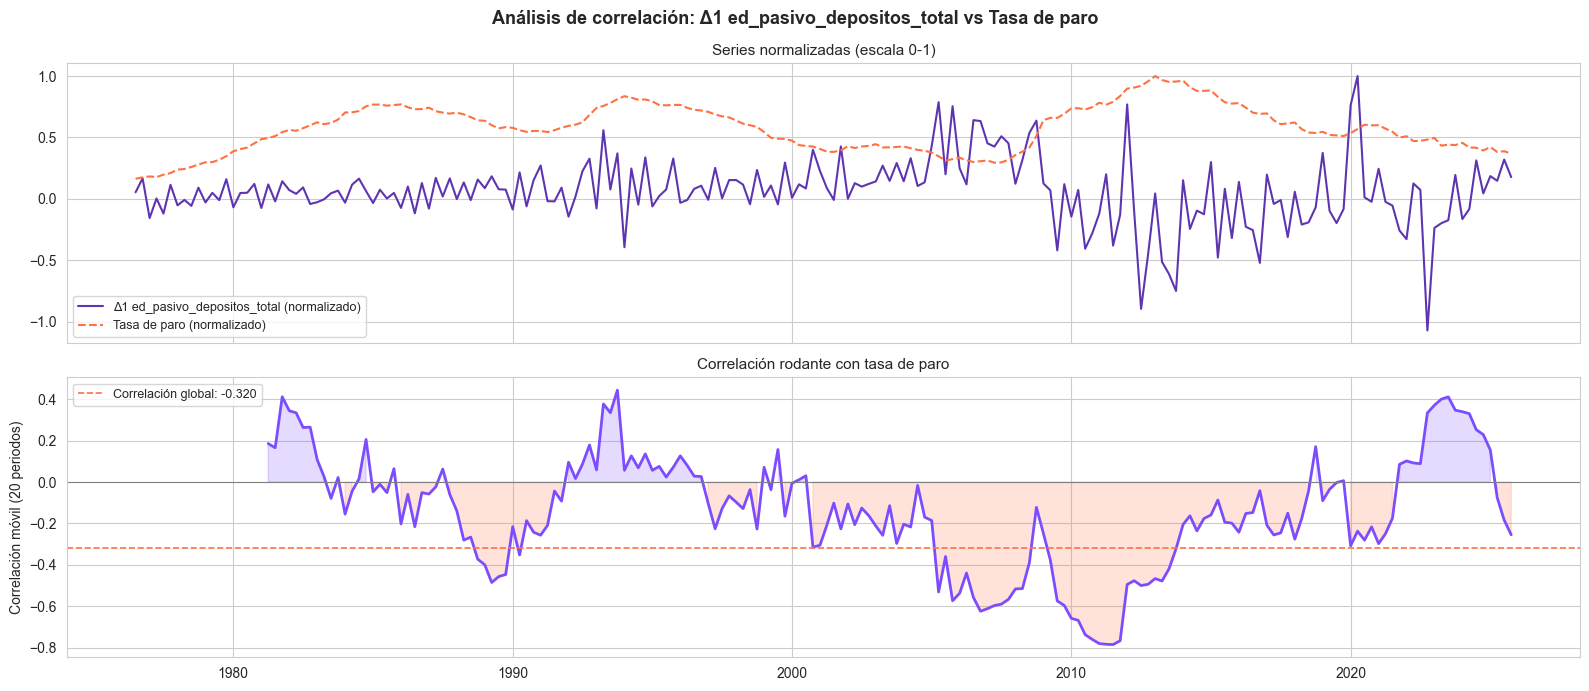

Correlación de Pearson global: -0.3203


In [70]:
ventana_corr = 20

df_cross = pd.DataFrame({'banca_pasivo': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['banca_pasivo'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['banca_pasivo'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['banca_pasivo'] / df_cross['banca_pasivo'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación global de Pearson entre Δ1 de `ed_pasivo_depositos_total` y `tasa_paro_ambos_sexos_total` es de -0,3203, valor moderado que la correlación rodante (ventana 20 periodos) muestra inestable y dependiente del régimen. La correlación móvil cruza el cero en múltiples ocasiones y recorre un rango aproximado entre -0,80 y +0,45: alcanza valores próximos a +0,40 en 1981-1982 y a +0,45 en 1993-1994, próximos a +0,40 en 2022-2023, y por el lado negativo desciende a valores cercanos a -0,50 en 1989-1990, próximos a -0,65 entre 2007 y 2010 y a -0,80 en torno a 2011-2012. La correlación rodante permanece por encima de la global de -0,3203 durante tramos prolongados de las décadas de los setenta, ochenta, mediados de los noventa, 2000-2005 y 2018-2023, y por debajo solo en episodios concretos asociados a recesión y a crisis de deuda. Este patrón indica que la relación lineal contemporánea entre el cambio en depósitos y el paro no es estable y se intensifica en sentido negativo en los episodios de crisis. La caracterización del cruzado se completa en la fase de feature engineering.### Análisis:

In [71]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='banca_pasivo', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Desempleo',
    labels={
        'banca_pasivo': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

La dispersión por décadas confirma la heterogeneidad de la relación detectada en la correlación rodante. La tendencia global describe una pendiente decreciente desde aproximadamente 22% de paro en Δ1 cercana a -170.000 millones hasta aproximadamente 10% en Δ1 próxima a +160.000 millones, consistente con la correlación global de -0,320. La nube de puntos presenta una elevada superposición entre décadas: los años 1970 (azul) y 2000 (morado) se concentran en la zona de paro bajo, entre el 5% y el 12%, con Δ1 mayoritariamente en la banda entre -25.000 y +100.000 millones; los años 1980 (verde) y 1990 (naranja) ocupan la franja intermedia de paro, entre el 13% y el 22%, con Δ1 en una banda similar; los años 2010 (amarillo) se sitúan en la parte alta del paro, entre el 17% y el 27%, con Δ1 repartida entre valores negativos próximos a -120.000 millones y positivos hasta aproximadamente +80.000 millones; los años 2020 (rosa) ocupan la franja del 10% al 16% de paro con la mayor dispersión de Δ1 de la muestra, entre aproximadamente -170.000 y +160.000 millones. La dispersión interna de cada década es elevada y la relación lineal global captura solo una parte del cruzado. La caracterización completa se resuelve en la fase de feature engineering.### Análisis:

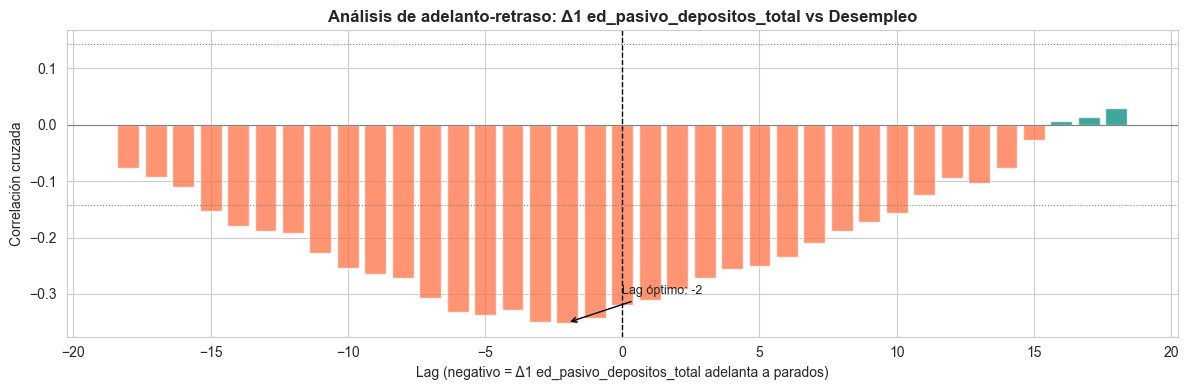

Lag con máxima correlación: -2 periodos
Correlación en ese lag: -0.3508
Banda de significancia (±2/√N): ±0.1421


In [72]:
max_lag = LAGS_ACF // 2

sa = (df_cross['banca_pasivo'] - df_cross['banca_pasivo'].mean()) / df_cross['banca_pasivo'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a parados)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Desempleo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de adelanto-retraso identifica un lag óptimo de -2 periodos con correlación cruzada de -0,3508, frente a una banda de significancia de ±0,1421. El signo negativo del lag indica que Δ1 de `ed_pasivo_depositos_total` adelanta a `tasa_paro_ambos_sexos_total`: los cambios trimestrales en depósitos preceden en aproximadamente dos trimestres a los movimientos en sentido opuesto del paro, un adelanto considerablemente más corto que el observado en otras series del proyecto. La correlación cruzada permanece negativa y por encima de la banda de significancia en sentido absoluto en todo el tramo de lags negativos desde aproximadamente -15 hasta 0, con un mínimo plano entre -5 y -2 en valores próximos a -0,35, y se mantiene negativa pero menos intensa en los lags positivos hasta aproximadamente +14, donde los coeficientes cruzan el cero hacia valores positivos próximos a 0,02 en los lags más largos, dentro o cerca de la banda de significancia. La estructura temporal es coherente con una relación inversa adelantada de Δ1 de depósitos respecto al paro, con un adelanto corto y una correlación máxima moderada. La caracterización completa de la relación temporal se resuelve en la fase de feature engineering.### Análisis: